# Evaluación de la deformación superficial asociada a movimientos en masa mediante análisis InSAR y datos GNSS en la cuenca media y baja del río Suárez, Colombia

## Componente InSAR: series temporales Sentinel-1 con HyP3 y MintPy

**Autores:** Mariana Paredes Galindo · Sair Granada Garzón  
**Director:** José Pedro Mora Ortiz — Geólogo, MSc. en Sistemas de Información Geográfica y MSc. en Geofísica  
**Codirector:** José Luis Gómez Díaz — Ing. Catastral y Geodesta, MSc. en Ciencias de la Geoinformación y Observación de la Tierra  

Universidad Industrial de Santander · Facultad de Ingenierías Fisicoquímicas · Escuela de Geología  
Bucaramanga, 2026

## 1. Dependencias del entorno de trabajo

**Ejecución:** una sola vez, o cuando se cambie de máquina o de entorno.

Esta celda verifica que las librerías necesarias estén instaladas en el núcleo (*kernel*) de Jupyter e instala únicamente las que falten, sin reinstalar las existentes. Para ello, `importlib.util.find_spec` comprueba si cada módulo puede importarse y `subprocess` invoca al gestor de paquetes `pip` con el mismo intérprete de Python del notebook (`sys.executable`), lo que garantiza que la instalación quede en el entorno activo (Python Software Foundation, 2024).

Las librerías verificadas corresponden a la búsqueda de escenas (`asf_search`; Alaska Satellite Facility [ASF], s.f.-a), la gestión de trabajos de interferometría en la nube (`hyp3_sdk`; Hogenson et al., 2020), el manejo de datos geoespaciales (`geopandas`, `rasterio`, `pyproj`), la lectura de los archivos HDF5 generados por MintPy (`h5py`; Collette, 2013) y la visualización del progreso (`tqdm`; da Costa-Luis, 2019). MintPy se ejecuta en un entorno conda independiente, descrito en la sección correspondiente.

In [32]:
import importlib.util, subprocess, sys

PAQUETES = {
    "hyp3_sdk": "hyp3-sdk",
    "asf_search": "asf-search",
    "geopandas": "geopandas",
    "rasterio": "rasterio",
    "h5py": "h5py",
    "pyproj": "pyproj",
    "tqdm": "tqdm",
}

faltantes = [pip for mod, pip in PAQUETES.items() if importlib.util.find_spec(mod) is None]
if faltantes:
    print("Instalando:", faltantes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


## 2. Librerías

**Ejecución:** siempre, al abrir el notebook.

Se importan en un solo lugar todas las librerías del flujo de procesamiento. La función de cada una es la siguiente:

| Librería / módulo | Función en el flujo | Referencia |
|---|---|---|
| `os`, `re`, `getpass`, `zipfile`, `shutil`, `time`, `subprocess`, `pathlib` | Biblioteca estándar de Python: variables de entorno, expresiones regulares, ingreso seguro de contraseñas, descompresión de productos, copia de archivos, medición de tiempos, ejecución de MintPy como proceso externo y manejo de rutas independiente del sistema operativo. | Python Software Foundation (2024) |
| `numpy` | Operaciones con arreglos numéricos: máscaras, estadísticas y álgebra lineal de la descomposición de velocidades. | Harris et al. (2020) |
| `pandas` | Tablas de escenas, pares interferométricos y resúmenes; manejo de fechas. | McKinney (2010) |
| `geopandas` | Tablas con geometría: polígono de la cuenca, huellas de las escenas y reproyección entre sistemas de coordenadas. | Jordahl et al. (2020) |
| `matplotlib` (`pyplot`, `dates`, `lines`) | Gráficas y mapas: red de interferogramas, coherencia, velocidad y series temporales. | Hunter (2007) |
| `rasterio` (`windows`, `transform`, `features`) | Lectura y escritura de GeoTIFF, recorte por ventanas, conversión entre coordenadas y píxeles, y enmascaramiento con el polígono de la cuenca. | Gillies et al. (2013) |
| `h5py` | Lectura de los archivos HDF5 que produce MintPy (`ifgramStack.h5`, `timeseries.h5`, `velocity.h5`). | Collette (2013) |
| `pyproj` (`Transformer`) | Transformación de coordenadas geográficas (latitud y longitud) a UTM, para ubicar puntos sobre los productos. | Snow et al. (2024) |
| `shapely` (`wkt`, `geometry`, `ops`, `validation`) | Geometrías vectoriales: lectura del polígono en formato WKT, reparación de geometrías inválidas, puntos, uniones e intersecciones. | Gillies et al. (2024) |
| `asf_search` | Búsqueda de escenas Sentinel-1 en el archivo del Alaska Satellite Facility. | ASF (s.f.-a) |
| `hyp3_sdk` (`HyP3`, `Batch`) | Envío, consulta y descarga de trabajos de interferometría en el servicio HyP3. | Hogenson et al. (2020) |
| `tqdm` | Barras de progreso en los procesos largos. | da Costa-Luis (2019) |

In [33]:
# Biblioteca estándar de Python
import os, re, getpass, zipfile, shutil, time, subprocess
from pathlib import Path

# Cálculo numérico y tablas
import numpy as np
import pandas as pd

# Datos geoespaciales vectoriales
import geopandas as gpd
from shapely import wkt
from shapely.geometry import shape, Point
from shapely.ops import unary_union
from shapely.validation import make_valid
from pyproj import Transformer

# Datos ráster (GeoTIFF de HyP3) y HDF5 (MintPy)
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.transform import from_origin, rowcol
from rasterio.features import geometry_mask
import h5py

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

# Acceso a datos Sentinel-1 y procesamiento en ASF HyP3
import asf_search as asf
from hyp3_sdk import HyP3, Batch

plt.rcParams.update({"font.size": 11})
print("Librerías cargadas")

Librerías cargadas


## 3. Rutas de trabajo

**Ejecución:** siempre, al abrir el notebook.

Se define el identificador de la corrida (`RUN_ID`) y se crea la estructura de carpetas del proyecto:

    inputs/
    └── HyP3_<RUN_ID>/              productos comprimidos descargados de HyP3
        ├── descomprimidos/<job>/   productos descomprimidos
        └── recortados/<job>/       GeoTIFF recortados (*_clip.tif), entrada de MintPy
    mintpy_<RUN_ID>/<job>/          un directorio de trabajo de MintPy por stack

MintPy requiere un directorio de trabajo independiente para cada stack, entendido como el conjunto de interferogramas con una misma geometría de adquisición (misma órbita y *frame*). Esta organización sigue la estructura recomendada en la documentación de MintPy para productos HyP3 (Yunjun et al., 2019), en el tutorial de series temporales del Alaska Satellite Facility (ASF, s.f.-b) y en los materiales del curso *InSAR Processing and Analysis* (EarthScope Consortium, 2026). El uso de `pathlib.Path` hace que las rutas funcionen igual en Linux, macOS y Windows.

In [6]:
import os, re, getpass, zipfile, shutil, time, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.transform import from_origin, rowcol
from rasterio.features import geometry_mask
import h5py
from pyproj import Transformer
from shapely.geometry import shape, Point
from shapely.ops import unary_union
import asf_search as asf
from hyp3_sdk import HyP3, Batch
from tqdm.auto import tqdm

BARRA_FORMATO = "{desc} {percentage:3.0f}% |{bar:35}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
RUN_ID = "suarez_2024_2026_v1"

INPUTS_DIR   = Path("./inputs")
DOWNLOAD_DIR = INPUTS_DIR / f"HyP3_{RUN_ID}"
UNZIP_DIR    = DOWNLOAD_DIR / "descomprimidos"
CLIP_DIR     = DOWNLOAD_DIR / "recortados"
MINTPY_ROOT  = Path(f"./mintpy_{RUN_ID}")

for carpeta in [INPUTS_DIR, DOWNLOAD_DIR, UNZIP_DIR, CLIP_DIR, MINTPY_ROOT]:
    carpeta.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"font.size": 11})
print("Rutas listas en:", Path.cwd())

Rutas listas en: /home/jovyan/Tesis_InSAR_Rio_Suarez


In [15]:
START = "2024-01-01"
END   = "2026-09-30"
FECHA_EVENTO_TXT = None                 # o "AAAA-MM-DD" si ya tiene la fecha
PUNTO_EVENTO = Point(-73.673, 6.012)    # (lon, lat) del evento

FECHA_EVENTO = pd.Timestamp(FECHA_EVENTO_TXT) if FECHA_EVENTO_TXT else None
gdf_cuenca = gpd.GeoDataFrame({"nombre": ["Cuenca Suárez"]}, geometry=[geom], crs="EPSG:4326")

archivo_pares = INPUTS_DIR / f"{RUN_ID}_pares.csv"
print("Evento:", FECHA_EVENTO.date() if FECHA_EVENTO else "sin fecha",
      "| punto:", PUNTO_EVENTO.wkt, "| dentro de la cuenca:", geom.contains(PUNTO_EVENTO))

Evento: sin fecha | punto: POINT (-73.673 6.012) | dentro de la cuenca: True


## 3. Autenticación Earthdata / HyP3
🔁 **Ejecutar siempre** (cada vez que abra el notebook). *(solo cuando vaya a usar HyP3: secciones 4 a 7)*

**Qué hace:** inicia sesión en HyP3 con la cuenta de NASA Earthdata que envió los trabajos y muestra los créditos disponibles.
**Referencia:** HyP3 SDK, *Authentication* y `HyP3.check_credits()` [R4].

In [7]:
user = input("Usuario Earthdata: ")
password = getpass.getpass("Contraseña Earthdata: ")
hyp3 = HyP3(username=user, password=password)
print("Créditos disponibles:", hyp3.check_credits())

Usuario Earthdata:  marianaparedes
Contraseña Earthdata:  ········


Créditos disponibles: 4970


## 4. Búsqueda de escenas Sentinel-1
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo. *(solo para consulta: no modifica nada)*

**Qué hace:** consulta en ASF las escenas **SLC IW** de Sentinel-1 que intersectan la cuenca simplificada (tolerancia 0.005° ≈ 550 m) y arma un `GeoDataFrame` con dirección de vuelo, *path*, *frame* y fecha. También marca qué escenas cubren el punto del evento.
**Referencia:** `asf_search.geo_search` y `ASFSearchResults.raise_if_incomplete()` [R6]; búsqueda de datos del curso ISCE+ (0.5_Data_Search_and_Access) [R1].

In [30]:
search_wkt = geom.simplify(0.005).wkt

START = "2024-01-01"
END   = "2026-09-30"            # sus pares llegan hasta 2026-09-14
FECHA_EVENTO_TXT = None   # o la fecha real, ej. "2025-04-12"
FECHA_EVENTO = pd.Timestamp(FECHA_EVENTO_TXT) if FECHA_EVENTO_TXT else None
PUNTO_EVENTO = Point(-73.673, 6.012)  # ← coordenada del evento (lon, lat)

res = asf.geo_search(
    intersectsWith=search_wkt,
    start=START,
    end=END,
    platform=asf.PLATFORM.SENTINEL1,
    beamMode="IW",
    processingLevel="SLC",
)
res.raise_if_incomplete()

scene_gdf = gpd.GeoDataFrame(
    [
        {
            "scene": r.properties["sceneName"],
            "dir": r.properties["flightDirection"],
            "path": r.properties["pathNumber"],
            "frame": r.properties["frameNumber"],
            "date": pd.to_datetime(r.properties["startTime"]).tz_localize(None).normalize(),
            "cubre_evento": shape(r.geometry).covers(PUNTO_EVENTO),
            "geometry": shape(r.geometry),
        }
        for r in res
    ],
    crs="EPSG:4326",
)
scene_gdf = (scene_gdf.drop_duplicates("scene")
             .sort_values(["dir", "path", "frame", "date"])
             .reset_index(drop=True))

print("Escenas encontradas:", len(scene_gdf))
display(scene_gdf.head())

Escenas encontradas: 537


,scene,dir,path,frame,date,cubre_evento,geometry
0,S1C_IW_SLC__1SDV_20250515T230450_20250515T2305...,ASCENDING,77,1195,2025-05-15,False,"POLYGON ((-73.39664 3.89734, -71.1698 4.36257,..."
1,S1C_IW_SLC__1SDV_20250608T230453_20250608T2305...,ASCENDING,77,1195,2025-06-08,False,"POLYGON ((-73.40122 3.89706, -71.17431 4.36229..."
2,S1C_IW_SLC__1SDV_20250702T230454_20250702T2305...,ASCENDING,77,1195,2025-07-02,False,"POLYGON ((-73.40051 3.89709, -71.1735 4.36238,..."
3,S1C_IW_SLC__1SDV_20250726T230456_20250726T2305...,ASCENDING,77,1195,2025-07-26,False,"POLYGON ((-73.40077 3.89741, -71.17386 4.36264..."
4,S1C_IW_SLC__1SDV_20250819T230457_20250819T2305...,ASCENDING,77,1195,2025-08-19,False,"POLYGON ((-73.40066 3.89784, -71.17381 4.36307..."


### 4.1 Cobertura de la cuenca y selección de stacks
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo.

**Qué hace:** agrupa las escenas por **(dirección, path, frame)**, que es un stack con geometría fija. Para cada stack calcula el área de la cuenca que cubre en **EPSG:3116 (MAGNA-SIRGAS / Colombia Bogotá)**, una proyección métrica, porque en grados no se pueden medir áreas. Conserva los stacks con más de 50 % de cobertura.
**Por qué:** MintPy solo invierte **stacks** con la misma geometría de adquisición. No se deben mezclar paths ni frames (curso ISCE+, nota "*the multiple pairs of interferograms is NOT a stack*" [R1]).
**Referencia:** GeoPandas `to_crs` y `area` [R15]; Shapely `unary_union` [R15].

In [ ]:
aoi_m2 = gdf_cuenca.to_crs(3116).area.iloc[0]
resumen = []

for (direccion, path, frame), grupo in tqdm(
    scene_gdf.groupby(["dir", "path", "frame"]),
    desc="Calculando cobertura", bar_format=BARRA_FORMATO, colour="#00B0FF", dynamic_ncols=True,
):
    huella = unary_union(grupo.geometry.tolist())
    cobertura = huella.intersection(geom)
    cobertura_m2 = gpd.GeoSeries([cobertura], crs="EPSG:4326").to_crs(3116).area.iloc[0]
    resumen.append({
        "dir": direccion, "path": path, "frame": frame,
        "n_fechas": grupo["date"].nunique(),
        "inicio": grupo["date"].min(), "fin": grupo["date"].max(),
        "antes_evento": (grupo["date"] < FECHA_EVENTO).sum(),
        "despues_evento": (grupo["date"] > FECHA_EVENTO).sum(),
        "evento_cubierto": grupo["cubre_evento"].any(),
        "cobertura_pct_cuenca": 100 * cobertura_m2 / aoi_m2,
        "geometry": huella,
    })

stacks_gdf = gpd.GeoDataFrame(resumen, crs="EPSG:4326")
stacks_gdf = stacks_gdf[stacks_gdf["cobertura_pct_cuenca"] > 50].copy()
stacks_gdf = stacks_gdf.sort_values(["evento_cubierto", "n_fechas"], ascending=[False, False]).reset_index(drop=True)

display(stacks_gdf.drop(columns="geometry"))
print("Stacks con más de 50 % de cobertura:", len(stacks_gdf))

### 4.2 Visualización de la cobertura espacial
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo.

**Qué hace:** dibuja la cuenca, el evento y las huellas de los stacks que tienen al menos `MIN_FECHAS` adquisiciones.
**Por qué:** con menos de unas 12 fechas, la inversión SBAS queda mal condicionada y la velocidad tiene mucha incertidumbre (Berardino et al., 2002 [P2]; Yunjun et al., 2019 [P1]).
**Referencia:** GeoPandas y Matplotlib [R15].

In [ ]:
MIN_FECHAS = 12
stacks_sel = stacks_gdf[stacks_gdf["n_fechas"] >= MIN_FECHAS].copy()

fig, ax = plt.subplots(figsize=(11, 12))
gdf_cuenca.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
colores = plt.cm.tab20(np.linspace(0, 1, max(len(stacks_sel), 1)))
handles = [Line2D([0], [0], color="black", lw=2, label="Cuenca")]

for color, (_, stack) in zip(colores, stacks_sel.iterrows()):
    gpd.GeoSeries([stack.geometry], crs="EPSG:4326").boundary.plot(ax=ax, color=color, linewidth=1.2)
    handles.append(Line2D([0], [0], color=color, lw=2,
                          label=f"{stack.dir[:3]} R{stack.path} F{stack.frame} | {stack.n_fechas} fechas | {stack.cobertura_pct_cuenca:.0f}%"))

ax.plot(PUNTO_EVENTO.x, PUNTO_EVENTO.y, "r*", ms=16)
handles.append(Line2D([0], [0], marker="*", color="red", markersize=14, linestyle="None", label="Evento Vélez"))
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set_title("Cobertura de stacks Sentinel-1")
plt.tight_layout(); plt.show()
print("Stacks seleccionados:", len(stacks_sel))

### 4.3 Construcción de la red de pares SBAS
🛑 **(solo se ejecuta 1 vez) — YA EJECUTADO.** Se deja como registro; está protegido para no gastar créditos.

**Qué hace:** en cada stack une cada fecha con sus `n_vecinos` fechas siguientes. Usa 2 vecinos si el stack cubre el evento y 1 si no. Estima el costo en créditos y guarda la tabla de pares en CSV.
**Protección añadida:** si el CSV ya existe **no lo sobrescribe**, porque es el registro de lo que se envió. Tampoco lanza error por falta de créditos cuando los trabajos ya fueron enviados.
**Por qué importa para MintPy:** con **1 vecino** la red es secuencial, sin triángulos. En ese caso (a) no se puede corregir el desenrollado por *phase closure* y (b) la **coherencia temporal sale ≈ 1 en todos los píxeles**, así que no sirve como filtro de calidad (pregunta planteada en el curso ISCE+ 5.1 [R1]). Con 2 vecinos sí hay triángulos. Las secciones 9 y 11 tienen esto en cuenta.
**Referencia:** red *small baseline* (Berardino et al., 2002 [P2]); ejemplo de red SBAS con HyP3 [R3]; costo por trabajo en créditos [R4].

In [ ]:
pares_lista = []
for _, stack_info in tqdm(stacks_sel.iterrows(), total=len(stacks_sel), desc="Construyendo pares SBAS",
                          bar_format=BARRA_FORMATO, colour="#00B0FF", dynamic_ncols=True):
    grupo = scene_gdf[(scene_gdf["dir"] == stack_info["dir"])
                      & (scene_gdf["path"] == stack_info["path"])
                      & (scene_gdf["frame"] == stack_info["frame"])].copy()
    grupo = grupo.drop_duplicates("date").sort_values("date").reset_index(drop=True)

    n_vecinos = 2 if stack_info["evento_cubierto"] else 1
    stack_id = f"{stack_info['dir']}_R{stack_info['path']}_F{stack_info['frame']}"
    job_name = f"{RUN_ID}_{stack_id}"

    for i in range(len(grupo)):
        for j in range(i + 1, min(i + 1 + n_vecinos, len(grupo))):
            pares_lista.append({
                "stack_id": stack_id, "job_name": job_name,
                "ref": grupo.scene.iloc[i], "sec": grupo.scene.iloc[j],
                "fecha_ref": grupo.date.iloc[i], "fecha_sec": grupo.date.iloc[j],
                "dias": (grupo.date.iloc[j] - grupo.date.iloc[i]).days,
            })

pares = pd.DataFrame(pares_lista)
COSTO_POR_PAR = 10
costo_estimado = len(pares) * COSTO_POR_PAR
print("Pares:", len(pares), "| Costo estimado:", costo_estimado)
display(pares.groupby("stack_id").size().rename("n_pares").reset_index())

archivo_pares = INPUTS_DIR / f"{RUN_ID}_pares.csv"
if archivo_pares.exists():
    print(f"⚠️ {archivo_pares} ya existe: NO se sobrescribe (registro de los trabajos enviados).")
else:
    pares.to_csv(archivo_pares, index=False)
    print("Guardado:", archivo_pares)

### 4.4 Envío de trabajos InSAR a HyP3
🛑 **(solo se ejecuta 1 vez) — YA EJECUTADO.** Se deja como registro; está protegido para no gastar créditos.

**Qué hace:** envía un trabajo `INSAR_GAMMA` por par, con 20×4 *looks* (píxel de unos 80 m), máscara de agua, DEM y vectores de mirada (`lv_theta`, `lv_phi`). MintPy necesita estos dos últimos para la geometría.
**Control:** `ENVIAR_A_HYP3 = False` impide volver a enviar y gastar créditos.
**Referencia:** `HyP3.submit_insar_job` [R4]; opciones de producto (`looks`, `include_look_vectors`, `apply_water_mask`) en la guía de productos InSAR de HyP3 [R5]; flujo del tutorial ASF [R3].

In [ ]:
ENVIAR_A_HYP3 = False   # 🛑 NO cambiar: los trabajos ya fueron enviados

if not ENVIAR_A_HYP3:
    print("Envío bloqueado: los trabajos ya fueron enviados y se recuperan desde HyP3.")
else:
    if costo_estimado > hyp3.check_credits():
        raise RuntimeError("Créditos insuficientes: no se enviaron trabajos.")
    jobs = Batch()
    for p in tqdm(pares.itertuples(), total=len(pares), desc="Enviando a HyP3",
                  bar_format=BARRA_FORMATO, colour="#FF9800", dynamic_ncols=True):
        jobs += hyp3.submit_insar_job(p.ref, p.sec, name=p.job_name,
                                      include_look_vectors=True, include_dem=True,
                                      apply_water_mask=True, looks="20x4")
    print("Trabajos enviados:", len(jobs), "| Créditos restantes:", hyp3.check_credits())

## 5. Recuperar los pares ya enviados
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** lee el CSV de pares guardado en 4.3. Todo lo que sigue usa la variable `pares` (nombres de trabajo, stacks y fechas).
**Referencia:** `pandas.read_csv` con `parse_dates`.

In [8]:
archivo_pares = INPUTS_DIR / f"{RUN_ID}_pares.csv"
if not archivo_pares.exists():
    raise FileNotFoundError(f"No se encontró {archivo_pares}")
pares = pd.read_csv(archivo_pares, parse_dates=["fecha_ref", "fecha_sec"])
JOBS = list(pares["job_name"].unique())
print("Pares recuperados:", len(pares), "| Stacks:", len(JOBS))
display(pares.groupby(["stack_id", "job_name"]).agg(n_pares=("ref", "size"),
        inicio=("fecha_ref", "min"), fin=("fecha_sec", "max")).reset_index())

Pares recuperados: 303 | Stacks: 3


,stack_id,job_name,n_pares,inicio,fin
0,ASCENDING_R77_F1199,suarez_2024_2026_v1_ASCENDING_R77_F1199,45,2025-05-03,2026-09-14
1,ASCENDING_R77_F1200,suarez_2024_2026_v1_ASCENDING_R77_F1200,33,2025-05-15,2026-09-02
2,DESCENDING_R69_F572,suarez_2024_2026_v1_DESCENDING_R69_F572,225,2024-01-03,2026-09-14


## 6. Estado de los trabajos en HyP3
🔁 *Opcional:* ejecútela para confirmar que no hay trabajos pendientes o fallidos antes de descargar.

**Qué hace:** para cada `job_name` cuenta los trabajos exitosos, pendientes y fallidos.
**Referencia:** `HyP3.find_jobs`, `HyP3.refresh` y `Batch.filter_jobs` [R4].

In [9]:
estado = []
for job_name in tqdm(JOBS, desc="Consultando estado", bar_format=BARRA_FORMATO):
    jobs_stack = hyp3.refresh(hyp3.find_jobs(name=job_name))
    exitosos = len(jobs_stack.filter_jobs(succeeded=True, running=False, failed=False))
    fallidos = len(jobs_stack.filter_jobs(succeeded=False, running=False, failed=True))
    estado.append({"job_name": job_name, "total": len(jobs_stack), "exitosos": exitosos,
                   "pendientes": len(jobs_stack) - exitosos - fallidos, "fallidos": fallidos})
estado_df = pd.DataFrame(estado)
display(estado_df)

Consultando estado   0% |                                   | 0/3 [00:00<?]

,job_name,total,exitosos,pendientes,fallidos
0,suarez_2024_2026_v1_DESCENDING_R69_F572,225,221,0,4
1,suarez_2024_2026_v1_ASCENDING_R77_F1199,45,45,0,0
2,suarez_2024_2026_v1_ASCENDING_R77_F1200,33,33,0,0


## 7. Descarga y descompresión de productos
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo.

**Qué hace:** descarga los `.zip` de los trabajos exitosos y los descomprime en `descomprimidos/<job>/`.
**Protección añadida:** si la carpeta del producto ya existe, **se salta la descarga**. Así, correr la celda otra vez no descarga todo de nuevo.
**Referencia:** `Job.download_files` [R4]; el paso *download and unzip* del tutorial ASF [R3]; MintPy exige descomprimir los productos HyP3 [R9].

In [14]:
descargados, saltados = 0, 0
for job_name in tqdm(JOBS, desc="Descargando productos", bar_format=BARRA_FORMATO):
    ok = hyp3.find_jobs(name=job_name).filter_jobs(succeeded=True, running=False, failed=False)
    destino_zip, destino_unzip = DOWNLOAD_DIR / job_name, UNZIP_DIR / job_name
    destino_zip.mkdir(parents=True, exist_ok=True)
    destino_unzip.mkdir(parents=True, exist_ok=True)

    for job in ok.jobs:
        producto = Path(job.files[0]["filename"]).stem   # nombre del producto = nombre de la carpeta del zip
        if (destino_unzip / producto).exists():
            saltados += 1
            continue
        for archivo_zip in job.download_files(destino_zip):
            with zipfile.ZipFile(archivo_zip) as zf:
                zf.extractall(destino_unzip)
        descargados += 1

print(f"Completado — descargados: {descargados} | ya existían: {saltados}")

Descargando productos   0% |                                   | 0/3 [00:00<?]

Completado — descargados: 0 | ya existían: 299


## 8. Recorte de interferogramas al área común
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo. *(se salta los archivos `_clip.tif` que ya existen)*

**Qué hace:** en cada stack calcula el **rectángulo común** a todos los pares, que es la intersección de los límites de sus DEM. Luego recorta a ese rectángulo, con lectura por ventanas de rasterio, las capas que necesita MintPy: `unw_phase`, `corr`, `dem`, `lv_theta`, `lv_phi` y `water_mask`. También copia los `.txt` de metadatos.
**Por qué:** MintPy necesita que todas las capas del stack tengan **la misma grilla**. Los productos HyP3 de un mismo stack cubren áreas algo distintas. Los `.txt` son obligatorios porque `prep_hyp3` saca de ellos las fechas, la línea base, el *heading* y la hora de adquisición [R9].
**Referencia:** es la versión con rasterio de `clip_hyp3_products_to_common_overlap()` del tutorial ASF, que usa `gdal.Translate(projWin=overlap)` [R3]. El sufijo `_clip` es el mismo del ejemplo de MintPy para HyP3 [R9]. Lectura por ventanas en rasterio [R14].

In [ ]:
SUFIJOS = ["unw_phase", "corr", "dem", "lv_theta", "lv_phi", "water_mask"]

for job_name in tqdm(JOBS, desc="Recortando interferogramas", bar_format=BARRA_FORMATO,
                     colour="#00B0FF", dynamic_ncols=True):
    origen, destino = UNZIP_DIR / job_name, CLIP_DIR / job_name
    destino.mkdir(parents=True, exist_ok=True)
    carpetas = sorted([c for c in origen.iterdir() if c.is_dir()])

    # 1) rectángulo común (intersección de los límites de los DEM)
    bounds = []
    for carpeta in carpetas:
        dem = next(carpeta.glob("*_dem.tif"), None)
        if dem is not None:
            with rasterio.open(dem) as src:
                bounds.append(src.bounds)
    if not bounds:
        print(f"Sin DEM: {job_name}")
        continue
    xmin, xmax = max(b.left for b in bounds), min(b.right for b in bounds)
    ymin, ymax = max(b.bottom for b in bounds), min(b.top for b in bounds)
    if xmin >= xmax or ymin >= ymax:
        raise ValueError(f"Sin área común para: {job_name}")

    # 2) recorte de cada capa a ese rectángulo
    for carpeta in carpetas:
        salida_par = destino / carpeta.name
        salida_par.mkdir(exist_ok=True)
        for sufijo in SUFIJOS:
            archivo = next(carpeta.glob(f"*_{sufijo}.tif"), None)
            if archivo is None:
                continue
            salida = salida_par / f"{archivo.stem}_clip.tif"
            if salida.exists():
                continue
            with rasterio.open(archivo) as src:
                ventana = from_bounds(xmin, ymin, xmax, ymax, transform=src.transform)
                ventana = ventana.round_offsets().round_lengths().intersection(Window(0, 0, src.width, src.height))
                datos = src.read(window=ventana)
                perfil = src.profile.copy()
                perfil.update(height=datos.shape[1], width=datos.shape[2], transform=src.window_transform(ventana))
                with rasterio.open(salida, "w", **perfil) as dst:
                    dst.write(datos)
        # 3) metadatos .txt (los necesita prep_hyp3 de MintPy)
        for txt in carpeta.glob("*.txt"):
            if not (salida_par / txt.name).exists():
                shutil.copy(txt, salida_par / txt.name)

print("Recorte completado")

### 8.1 Verificación de los insumos recortados
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** para cada par revisa que estén las 6 capas y el `.txt` de metadatos, y que todas las capas del stack tengan **la misma forma, transformada y CRS**. Las que no coincidan se marcan como faltantes. Además lee de cada `.txt` la línea base perpendicular (`Baseline`) y arma la tabla `insumos` que usan las secciones 9 y 10.
**Por qué:** un par sin su `.txt` o con otra grilla hace fallar `load_data` de MintPy con errores poco claros. Es mejor detectarlo aquí.
**Referencia:** convención de nombres de HyP3 GAMMA `S1xx_YYYYMMDDTHHMMSS_YYYYMMDDTHHMMSS_...` y metadatos `.txt` [R5]; lectura de fechas en `mintpy/prep_hyp3.py` (`product_name.split('_')[1:3]`) [R7].

In [11]:
SUFIJOS = ["unw_phase", "corr", "dem", "lv_theta", "lv_phi", "water_mask"]

def fechas_desde_producto(nombre):
    """Devuelve (fecha_ref, fecha_sec) a partir del nombre de un producto HyP3 INSAR_GAMMA.
    Ejemplo: S1AA_20240105T105321_20240117T105320_VVP012_INT80_G_ueF_1A2B → 2024-01-05, 2024-01-17.
    Es el mismo criterio que usa mintpy/prep_hyp3.py [R7]."""
    partes = nombre.split("_")
    return pd.Timestamp(partes[1][:8]), pd.Timestamp(partes[2][:8])


def leer_baseline(txt):
    """Lee la línea base perpendicular (m) del .txt de metadatos HyP3 (clave 'Baseline'). NaN si no está."""
    try:
        for linea in Path(txt).read_text().splitlines():
            if linea.strip().lower().startswith("baseline"):
                return float(linea.split(":")[1])
    except Exception:
        pass
    return np.nan


def verificar_stack(job_name):
    """Revisa integridad y consistencia de grilla de un stack recortado.
    Devuelve un DataFrame con una fila por par y lanza error si las grillas no coinciden."""
    filas, firma_ref = [], None
    for carpeta in sorted(c for c in (CLIP_DIR / job_name).iterdir() if c.is_dir()):
        f1, f2 = fechas_desde_producto(carpeta.name)
        fila = {"producto": carpeta.name, "fecha1": f1, "fecha2": f2, "dias": (f2 - f1).days}
        for sufijo in SUFIJOS:
            arch = next(carpeta.glob(f"*_{sufijo}_clip.tif"), None)
            fila[sufijo] = arch is not None
            if arch is not None:
                with rasterio.open(arch) as src:
                    firma = (src.shape, tuple(round(v, 3) for v in src.transform[:6]), src.crs.to_epsg())
                firma_ref = firma_ref or firma
                if firma != firma_ref:
                    print(f"  ⚠️ Grilla distinta en {arch.name}: {firma} vs {firma_ref} (vuelva a recortar ese par)")
                    fila[sufijo] = False
        txt = carpeta / f"{carpeta.name}.txt"
        fila["txt"] = txt.exists()
        fila["bperp_m"] = leer_baseline(txt) if txt.exists() else np.nan
        filas.append(fila)
    df = pd.DataFrame(filas)
    df.attrs["grilla"] = firma_ref
    return df


insumos = {}
for job_name in JOBS:
    df = verificar_stack(job_name)
    insumos[job_name] = df
    incompletos = df[~df[SUFIJOS + ["txt"]].all(axis=1)]
    (forma, _, epsg) = df.attrs["grilla"]
    print(f"\n{job_name}\n  pares: {len(df)} | fechas: {pd.concat([df.fecha1, df.fecha2]).nunique()} "
          f"| grilla: {forma[0]}×{forma[1]} px | EPSG:{epsg}")
    if len(incompletos):
        print("  ⚠️ Pares incompletos:")
        display(incompletos[["producto"] + SUFIJOS + ["txt"]])
    else:
        print("  ✅ Todas las capas y metadatos presentes.")


suarez_2024_2026_v1_DESCENDING_R69_F572
  pares: 221 | fechas: 114 | grilla: 2393×3509 px | EPSG:32618
  ✅ Todas las capas y metadatos presentes.

suarez_2024_2026_v1_ASCENDING_R77_F1199
  pares: 45 | fechas: 24 | grilla: 2715×3603 px | EPSG:32618
  ✅ Todas las capas y metadatos presentes.

suarez_2024_2026_v1_ASCENDING_R77_F1200
  pares: 33 | fechas: 18 | grilla: 2943×3649 px | EPSG:32618
  ✅ Todas las capas y metadatos presentes.


# 9. Preparación de MintPy

MintPy (*Miami INsar Time-series software in PYthon*) invierte un **stack** de interferogramas desenrollados para obtener la serie temporal de desplazamiento en la línea de vista (LOS). Después corrige el ruido: mareas terrestres, troposfera, error de DEM, etc. (Yunjun et al., 2019 [P1]). El programa principal es `smallbaselineApp.py`, que corre estos pasos en orden [R8]:

`load_data → modify_network → reference_point → quick_overview → correct_unwrap_error → invert_network → correct_LOD → correct_SET → correct_ionosphere → correct_troposphere → deramp → correct_topography → residual_RMS → reference_date → velocity → geocode → google_earth → hdfeos5`

Como en el curso ISCE+ 2026 (notebooks `4.4_Intro_to_MintPy/smallbaselineApp_nisar.ipynb` y `5.1_TSAnalysis_with_MintPy_ErrorAnalysis/smallbaselineApp_aria.ipynb` [R1]), aquí se corre **por bloques de pasos** para revisar la red y la calidad **antes** de invertir. Los productos HyP3 ya vienen geocodificados (UTM), así que `geocode` no hace nada.

## 9.1 Entorno de MintPy
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo.

**Qué hace:** crea un entorno conda aparte (`~/.conda/envs/mintpy`) con MintPy, PyAPS3 (troposfera ERA5) y PySolid (mareas terrestres). Si el entorno ya existe, no hace nada.
**Por qué:** en OpenScienceLab, instalar MintPy con `pip` en el kernel choca con GDAL y PROJ (el error de `proj.db` que le salió antes). El curso recomienda un entorno conda propio y MintPy ≥ 1.6.
**Referencia:** instalación de MintPy [R10]; `S07_Installing_the_course_environment_with_conda` del curso ISCE+ 2026 [R1]; PyAPS [R12]; PySolid [R13].

In [12]:
MINTPY_ENV = Path.home() / ".conda" / "envs" / "mintpy"
MINTPY_PYTHON = MINTPY_ENV / "bin" / "python"

if MINTPY_PYTHON.exists():
    print("El entorno MintPy ya existe:", MINTPY_ENV)
else:
    gestor = shutil.which("mamba") or shutil.which("conda")
    if gestor is None:
        raise RuntimeError("No se encontró conda/mamba en este servidor.")
    subprocess.run([gestor, "create", "-y", "-p", str(MINTPY_ENV), "-c", "conda-forge",
                    "python=3.11", "mintpy>=1.6.1", "pyaps3>=0.3.6", "pysolid", "gdal", "h5py"],
                   check=True)
    print("Entorno creado:", MINTPY_ENV)

El entorno MintPy ya existe: /home/jovyan/.conda/envs/mintpy


## 9.2 Función para ejecutar MintPy desde el notebook
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** define `ejecutar_mintpy(modulo, args, cwd)`, que corre cualquier comando de MintPy (`smallbaselineApp`, `view`, `plot_network`, …) **con el Python del entorno MintPy**, de dos formas:
- `python -m mintpy.cli.<modulo>`, que equivale a `<modulo>.py` en la terminal;
- con `PROJ_DATA`, `PROJ_LIB` y `GDAL_DATA` apuntando al entorno, lo que evita el error de `proj.db`, y con `MPLBACKEND=Agg` para que las gráficas se guarden sin abrir ventanas.

Toda la salida queda en un **log por stack** (`log_mintpy.txt`). Si hay un error, muestra las últimas líneas del log.
**Referencia:** los scripts de `mintpy/cli/*.py` son ejecutables como módulo (`if __name__ == "__main__": main(sys.argv[1:])`) [R7]; uso de `smallbaselineApp.py --start/--end/--dostep` [R1], [R8].

In [13]:
MINTPY_ENV = Path.home() / ".conda" / "envs" / "mintpy"
MINTPY_PYTHON = MINTPY_ENV / "bin" / "python"

def entorno_mintpy():
    """Variables de entorno para los subprocesos de MintPy (PROJ/GDAL del entorno conda, backend sin pantalla)."""
    env = os.environ.copy()
    env["PATH"] = f"{MINTPY_ENV / 'bin'}{os.pathsep}{env.get('PATH', '')}"
    env["PROJ_DATA"] = env["PROJ_LIB"] = str(MINTPY_ENV / "share" / "proj")
    env["GDAL_DATA"] = str(MINTPY_ENV / "share" / "gdal")
    env["MPLBACKEND"] = "Agg"
    return env


def ejecutar_mintpy(modulo, args, cwd, log_nombre="log_mintpy.txt", check=True):
    """Ejecuta `python -m mintpy.cli.<modulo> <args>` dentro de `cwd` con el entorno MintPy.
    La salida se agrega a cwd/log_nombre. Devuelve el código de salida."""
    cwd = Path(cwd)
    cmd = [str(MINTPY_PYTHON), "-m", f"mintpy.cli.{modulo}", *map(str, args)]
    log = cwd / log_nombre
    with open(log, "a", encoding="utf-8") as f:
        f.write(f"\n\n===== {time.strftime('%Y-%m-%d %H:%M:%S')} :: {' '.join(cmd[2:])}\n")
        f.flush()
        proc = subprocess.run(cmd, cwd=cwd, env=entorno_mintpy(), stdout=f, stderr=subprocess.STDOUT)
    if proc.returncode != 0:
        cola = log.read_text(encoding="utf-8", errors="ignore").splitlines()[-25:]
        print(f"❌ {modulo} falló en {cwd.name} (código {proc.returncode}). Últimas líneas del log:")
        print("\n".join(cola))
        if check:
            raise RuntimeError(f"MintPy {modulo} falló en {cwd}")
    return proc.returncode


# Chequeo de versiones del entorno MintPy
salida = subprocess.run(
    [str(MINTPY_PYTHON), "-c",
     "import mintpy, pyaps3, pysolid; print(mintpy.__version__, pyaps3.__version__, pysolid.__version__)"],
    capture_output=True, text=True, env=entorno_mintpy())
print("MintPy / PyAPS3 / PySolid:", salida.stdout.strip() or salida.stderr.strip()[-400:])

MintPy / PyAPS3 / PySolid: 1.6.4 0.3.7 0.3.4


## 9.3 Red de interferogramas antes de MintPy
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** para cada stack:
1. comprueba si la red está **conectada**, con *union-find* sobre las fechas. Si hay subconjuntos desconectados, la inversión SBAS no tiene solución única;
2. cuenta los **triángulos** (i→j, j→k, i→k), que son la condición para corregir errores de desenrollado por *phase closure*;
3. grafica la red en el espacio **tiempo vs. línea base perpendicular**, que es la figura `network.pdf` del curso. La Bperp de cada fecha se estima por mínimos cuadrados a partir de la Bperp de los pares.

**Referencia:** red SBAS y conectividad (Berardino et al., 2002 [P2]); *phase closure* y triángulos (Yunjun et al., 2019, sección 3.2 [P1]); `plot_network.py` del curso ISCE+ [R1].

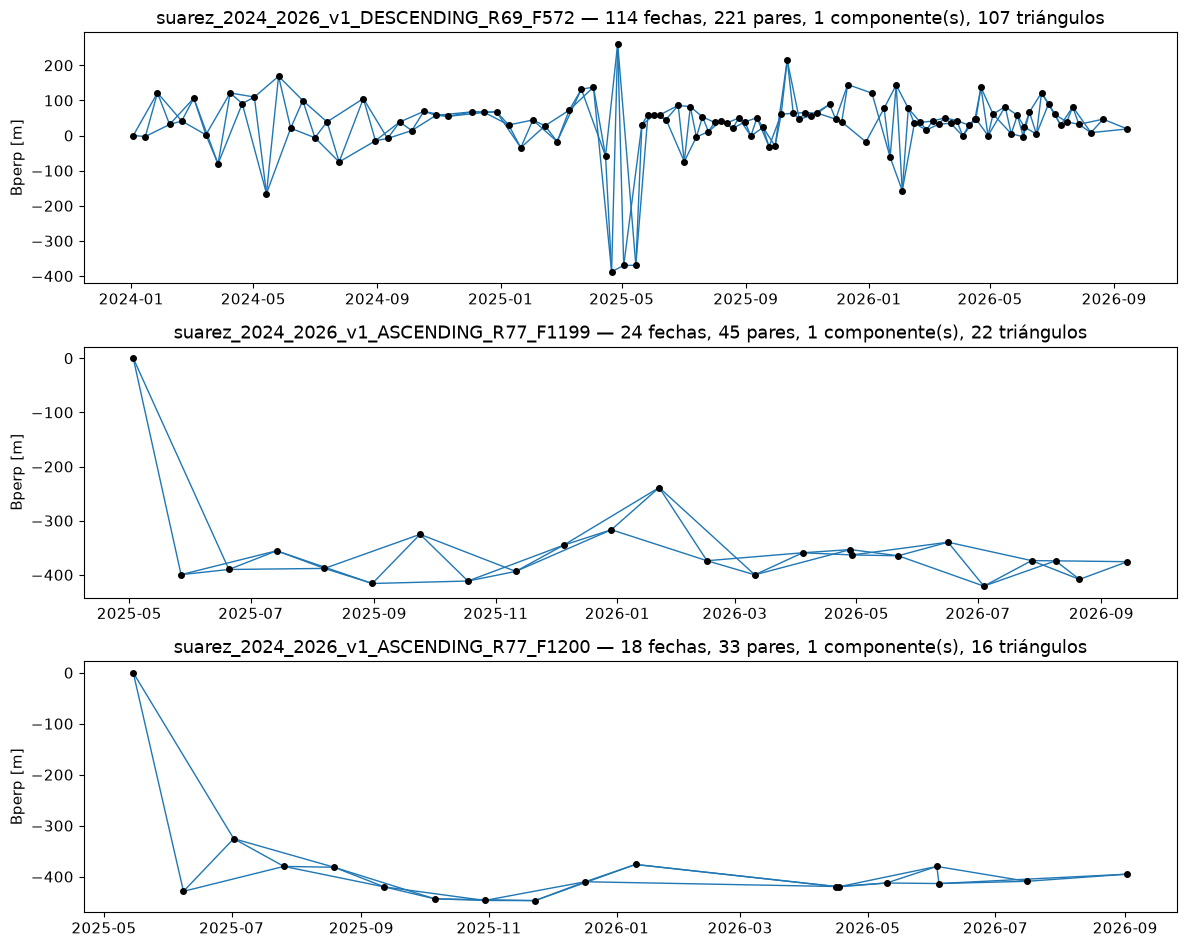

,n_fechas,n_pares,componentes,triangulos
suarez_2024_2026_v1_DESCENDING_R69_F572,114,221,1,107
suarez_2024_2026_v1_ASCENDING_R77_F1199,24,45,1,22
suarez_2024_2026_v1_ASCENDING_R77_F1200,18,33,1,16


In [16]:
def analizar_red(df):
    """Devuelve (fechas, n_componentes, n_triangulos, bperp_por_fecha) de una red de pares."""
    fechas = sorted(set(df.fecha1) | set(df.fecha2))
    idx = {f: i for i, f in enumerate(fechas)}
    padre = list(range(len(fechas)))

    def raiz(i):
        while padre[i] != i:
            padre[i] = padre[padre[i]]
            i = padre[i]
        return i

    for a, b in zip(df.fecha1, df.fecha2):
        padre[raiz(idx[a])] = raiz(idx[b])
    n_comp = len({raiz(i) for i in range(len(fechas))})

    aristas = {(idx[a], idx[b]) for a, b in zip(df.fecha1, df.fecha2)}
    n_tri = sum(1 for (i, j) in aristas for (j2, k) in aristas if j2 == j and (i, k) in aristas)

    # Bperp por fecha: B[sec] - B[ref] = bperp_par, con B[primera fecha] = 0
    A = np.zeros((len(df), len(fechas)))
    for n, (a, b) in enumerate(zip(df.fecha1, df.fecha2)):
        A[n, idx[a]], A[n, idx[b]] = -1, 1
    bp = df.bperp_m.fillna(0).to_numpy()
    sol = np.linalg.lstsq(A[:, 1:], bp, rcond=None)[0] if len(fechas) > 1 else np.array([])
    return fechas, n_comp, n_tri, np.r_[0, sol]


info_red = {}
fig, axes = plt.subplots(len(JOBS), 1, figsize=(12, 3.2 * len(JOBS)), squeeze=False)
for ax, job_name in zip(axes[:, 0], JOBS):
    df = insumos[job_name]
    fechas, n_comp, n_tri, bp = analizar_red(df)
    info_red[job_name] = {"n_fechas": len(fechas), "n_pares": len(df), "componentes": n_comp, "triangulos": n_tri}
    pos = dict(zip(fechas, bp))
    for a, b in zip(df.fecha1, df.fecha2):
        ax.plot([a, b], [pos[a], pos[b]], "-", color="#1f77b4", lw=1)
    ax.plot(fechas, bp, "o", color="k", ms=4)
    if FECHA_EVENTO: ax.axvline(FECHA_EVENTO, color="r", ls="--", lw=1, label="Evento")
    ax.set_title(f"{job_name} — {len(fechas)} fechas, {len(df)} pares, {n_comp} componente(s), {n_tri} triángulos")
    ax.set_ylabel("Bperp [m]")
plt.tight_layout(); plt.show()

display(pd.DataFrame(info_red).T)
for job, d in info_red.items():
    if d["componentes"] > 1:
        print(f"⚠️ {job}: red DESCONECTADA ({d['componentes']} partes). MintPy invertirá, pero los "
              "desplazamientos entre las partes no quedan bien determinados (revise fechas faltantes).")

## 9.4 Corrección troposférica: credenciales de ERA5 (CDS)
⚠️ **(solo se ejecuta 1 vez)** — ya se ejecutó; no volver a correr salvo que falte algo. *(crear `~/.cdsapirc`)* · luego 🔁 la verificación

**Qué hace:** revisa que exista `~/.cdsapirc` con el **formato nuevo** del Copernicus Climate Data Store: `url: https://cds.climate.copernicus.eu/api` y `key: <token>`. PyAPS3 necesita este archivo para descargar ERA5. Si no está, la celda puede crearlo pidiendo el token. Si no hay credenciales, el método troposférico cambia solo a `height_correlation`.
**Por qué:** en los Andes, el retardo troposférico **estratificado** (correlacionado con la altura) suele ser la señal de ruido más fuerte, por los desniveles de más de 2000 m en la cuenca. ERA5 lo modela con reanálisis (Jolivet et al., 2011 [P4]; Hersbach et al., 2020 [P9]). `height_correlation` lo estima empíricamente con la relación fase–elevación (Doin et al., 2009 [P10]). Antes debe **aceptar la licencia de ERA5** en la página del CDS.
**Referencia:** configuración de la cuenta en PyAPS [R12]; la validación del formato está en `mintpy/tropo_pyaps3.py::check_pyaps_account_config` [R7]; módulo 3.4_Tropo_Iono_Correction del curso ISCE+ [R1].

In [19]:
CDSRC = Path.home() / ".cdsapirc"
CREAR_CDSAPIRC = False   # ⚠️ después de crearlo, vuelva a poner False

if CREAR_CDSAPIRC:
    token = getpass.getpass("Pegue su token del CDS y oprima Enter: ").strip()
    if token.lower().startswith("key:"):
        token = token.split(":", 1)[1].strip()   # por si pegó la línea completa
    CDSRC.write_text(f"url: https://cds.climate.copernicus.eu/api\nkey: {token}\n")
    CDSRC.chmod(0o600)
    print("Archivo creado:", CDSRC)


def revisar_cds():
    """True si ~/.cdsapirc existe y tiene la URL nueva que exige MintPy/PyAPS3."""
    if not CDSRC.exists():
        return False, "No existe ~/.cdsapirc"
    partes = CDSRC.read_text().split()
    if partes[:2] != ["url:", "https://cds.climate.copernicus.eu/api"]:
        return False, "Formato antiguo: la url debe ser https://cds.climate.copernicus.eu/api"
    if len(partes) < 4 or partes[2] != "key:" or len(partes[3]) < 20:
        return False, "Falta el token en la línea 'key:'"
    return True, "OK"


cds_ok, msg = revisar_cds()
METODO_TROPO = "pyaps" if cds_ok else "height_correlation"
print("CDS:", msg, "→ método troposférico:", METODO_TROPO)

CDS: OK → método troposférico: pyaps


## 9.5 Parámetros de MintPy
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** reúne en un solo lugar las opciones que más afectan el resultado, cada una con su justificación. El resto queda en `auto`, que usa los valores por defecto de `smallbaselineApp_auto.cfg`.

| Parámetro | Valor | Justificación |
|---|---|---|
| `load.processor` | `hyp3` | Productos HyP3 GAMMA [R9]. `lv_theta` y `lv_phi` se convierten solos a ángulo de incidencia y azimut (`stackDict.py`: `inc = 90 − θ`) [R7]. |
| `subset.lalo` | caja de la cuenca + 0.02° | Reduce el cálculo y la memoria. Solo se procesa la cuenca [R8]. |
| `network.coherenceBased` | `yes`, `minCoherence 0.4`, `keepMinSpanTree yes` | Quita pares de baja coherencia (vegetación tropical) sin romper la red, porque se conserva el árbol de expansión mínima [R8], [P1]. El valor por defecto (0.7) es muy estricto para banda C en zonas vegetadas. |
| `reference.lalo` | `auto` o punto estable | Por defecto se elige el píxel de mayor coherencia. `minCoherence` se baja a 0.5, porque 0.85 casi no se alcanza en la cuenca. **Recomendado:** un punto estable y coherente lejos del evento, el mismo para todos los stacks (necesario en la sección 12) [R1], [R8]. |
| `unwrapError.method` | `phase_closure` si hay triángulos; si no, `no` | `bridging` necesita componentes conectadas, y HyP3 GAMMA no las entrega. *Phase closure* necesita triángulos [P1], [R1]. |
| `networkInversion.weightFunc` | `var` | Pondera cada interferograma por la varianza de la fase, estimada a partir de la coherencia [P1]. |
| `solidEarthTides` | `yes` | Mareas terrestres con PySolid (Yunjun et al., 2022 [P5]) [R13]. |
| `troposphericDelay.method` | `pyaps` (ERA5) o `height_correlation` | Ver 9.4 [P4], [P10]. |
| `deramp` | `no` | La cuenca es pequeña (≈ 90 km) y quitar una rampa puede borrar deformación real. Use `linear` solo si ve rampas de órbita o ionosfera en los resultados [R1]. |
| `topographicResidual` | `yes` + `stepDate` = evento | Error de DEM (Fattahi & Amelung, 2013 [P3]). El escalón evita que el salto del evento se interprete como error de DEM [R8]. |
| `timeFunc` | polinomio 1 + periodos `1.0, 0.5` años + escalón en el evento | Velocidad lineal, estacionalidad **bimodal** de las lluvias andinas (dos temporadas lluviosas al año) y salto del evento (Hetland et al., 2012 [P7]; curso ISCE+ 5.1, sección 6.1 [R1]). |
| `compute.cluster` | `local` | Paraleliza con Dask `invert_network` y `correct_topography` [R1], [R8]. |

In [20]:
REF_LALO = None            # ej. (6.35, -73.45): punto estable y coherente, lejos del evento. None = automático
COH_RED_MIN = 0.4          # mintpy.network.minCoherence
USAR_SUBSET_CUENCA = True  # recortar el procesamiento a la caja de la cuenca
BUFFER_GRADOS = 0.02
PERIODOS = "1.0,0.5"       # anual + semestral (régimen bimodal de lluvias)
DERAMP = "no"              # "no" | "linear" | "quadratic"
N_WORKERS = max(1, min(4, (os.cpu_count() or 2) - 1))
WEATHER_DIR = (MINTPY_ROOT / "ERA5").resolve()   # carpeta compartida de modelos meteorológicos
WEATHER_DIR.mkdir(exist_ok=True)

w, s, e, n = geom.bounds
SUBSET_LALO = f"{s - BUFFER_GRADOS:.4f}:{n + BUFFER_GRADOS:.4f},{w - BUFFER_GRADOS:.4f}:{e + BUFFER_GRADOS:.4f}"
FECHA_EVENTO_MINTPY = FECHA_EVENTO.strftime("%Y%m%d") if FECHA_EVENTO else "no"
print("Subset (S:N,W:E):", SUBSET_LALO, "| Escalón en:", FECHA_EVENTO_MINTPY, "| Workers:", N_WORKERS)

Subset (S:N,W:E): 5.3831:6.8104,-73.8807:-73.0501 | Escalón en: no | Workers: 3


## 9.6 Escritura del archivo de configuración de cada stack
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** `construir_config()` escribe `mintpy_<RUN_ID>/<job>/config.txt` con un comentario en cada opción. Estas opciones tienen prioridad sobre el `smallbaselineApp.cfg` por defecto, que MintPy copia al directorio de trabajo y actualiza solo.
- El **escalón** solo se incluye si el evento cae **dentro** del periodo del stack. Si no, la matriz de diseño quedaría singular.
- `unwrapError.method` se decide según los triángulos que tenga la red (9.3).

**Referencia:** plantilla completa con todas las opciones y sus valores por defecto: `smallbaselineApp.cfg` [R8]. Configuración HyP3 con `*_clip.tif` según la documentación de MintPy [R9] y el tutorial ASF [R3]. Formato de configuración propia del curso ISCE+ (`CONFIG_TXT`) [R1].

In [21]:
def construir_config(job_name):
    """Crea el config.txt de MintPy para un stack y devuelve su ruta."""
    carpeta_clip = (CLIP_DIR / job_name).resolve()
    mintpy_dir = MINTPY_ROOT / job_name
    mintpy_dir.mkdir(parents=True, exist_ok=True)

    df = insumos[job_name]
    f0, f1 = df.fecha1.min(), df.fecha2.max()
    hay_evento = FECHA_EVENTO is not None and f0 < FECHA_EVENTO < f1
    step = FECHA_EVENTO_MINTPY if hay_evento else "no"
    unwrap = "no"   # HyP3 no trae connectComponent, necesario para corregir
    ref = f"{REF_LALO[0]},{REF_LALO[1]}" if REF_LALO else "auto"

    opciones = [
        ("## ---------- cómputo", None, None),
        ("mintpy.compute.cluster", "local", "Dask en local [R8]"),
        ("mintpy.compute.numWorker", N_WORKERS, ""),
        ("## ---------- carga de datos HyP3 [R9]", None, None),
        ("mintpy.load.processor", "hyp3", ""),
        ("mintpy.load.unwFile", f"{carpeta_clip}/*/*_unw_phase_clip.tif", "fase desenrollada (rad)"),
        ("mintpy.load.corFile", f"{carpeta_clip}/*/*_corr_clip.tif", "coherencia"),
        ("mintpy.load.demFile", f"{carpeta_clip}/*/*_dem_clip.tif", "DEM (m)"),
        ("mintpy.load.incAngleFile", f"{carpeta_clip}/*/*_lv_theta_clip.tif", "MintPy convierte θ → incidencia"),
        ("mintpy.load.azAngleFile", f"{carpeta_clip}/*/*_lv_phi_clip.tif", "MintPy convierte φ → azimut LOS"),
        ("mintpy.load.waterMaskFile", f"{carpeta_clip}/*/*_water_mask_clip.tif", ""),
        ("mintpy.subset.lalo", SUBSET_LALO if USAR_SUBSET_CUENCA else "auto", "S:N,W:E"),
        ("## ---------- red y referencia", None, None),
        ("mintpy.network.coherenceBased", "yes", ""),
        ("mintpy.network.minCoherence", COH_RED_MIN, "por defecto 0.7: muy estricto en zona vegetada"),
        ("mintpy.network.keepMinSpanTree", "yes", "no romper la red"),
        ("mintpy.reference.lalo", ref, ""),
        ("mintpy.reference.minCoherence", 0.5, "por defecto 0.85"),
        ("## ---------- inversión", None, None),
        ("mintpy.unwrapError.method", unwrap, f"{info_red[job_name]['triangulos']} triángulos en la red"),
        ("mintpy.networkInversion.weightFunc", "var", "[P1]"),
        ("mintpy.networkInversion.minTempCoh", 0.7, ""),
        ("## ---------- correcciones", None, None),
        ("mintpy.solidEarthTides", "yes", "PySolid [P5]"),
        ("mintpy.troposphericDelay.method", METODO_TROPO, "[P4]/[P10]"),
        ("mintpy.troposphericDelay.weatherModel", "ERA5", ""),
        ("mintpy.troposphericDelay.weatherDir", WEATHER_DIR, ""),
        ("mintpy.deramp", DERAMP, ""),
        ("mintpy.topographicResidual", "yes", "[P3]"),
        ("mintpy.topographicResidual.stepDate", step, "evento"),
        ("## ---------- funciones temporales / velocidad [P7]", None, None),
        ("mintpy.timeFunc.polynomial", 1, "velocidad lineal"),
        ("mintpy.timeFunc.periodic", PERIODOS, "anual + semestral"),
        ("mintpy.timeFunc.stepDate", step, "salto del evento"),
        ("## ---------- salidas", None, None),
        ("mintpy.save.kmz", "yes", "Google Earth"),
        ("mintpy.plot", "yes", "figuras en pic/"),
    ]

    lineas = [f"# Configuración MintPy — {job_name} — generado {time.strftime('%Y-%m-%d %H:%M')}"]
    for clave, valor, comentario in opciones:
        if valor is None:
            lineas.append("\n" + clave)
        else:
            lineas.append(f"{clave:<42} = {valor}" + (f"   # {comentario}" if comentario else ""))
    ruta = mintpy_dir / "config.txt"
    ruta.write_text("\n".join(lineas) + "\n", encoding="utf-8")
    return ruta


for job_name in JOBS:
    ruta = construir_config(job_name)
    print("✅", ruta)
print("\nEjemplo:\n")
print((MINTPY_ROOT / JOBS[0] / "config.txt").read_text())

✅ mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_DESCENDING_R69_F572/config.txt
✅ mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_ASCENDING_R77_F1199/config.txt
✅ mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_ASCENDING_R77_F1200/config.txt

Ejemplo:

# Configuración MintPy — suarez_2024_2026_v1_DESCENDING_R69_F572 — generado 2026-09-29 16:17

## ---------- cómputo
mintpy.compute.cluster                     = local   # Dask en local [R8]
mintpy.compute.numWorker                   = 3

## ---------- carga de datos HyP3 [R9]
mintpy.load.processor                      = hyp3
mintpy.load.unwFile                        = /home/jovyan/Tesis_InSAR_Rio_Suarez/inputs/HyP3_suarez_2024_2026_v1/recortados/suarez_2024_2026_v1_DESCENDING_R69_F572/*/*_unw_phase_clip.tif   # fase desenrollada (rad)
mintpy.load.corFile                        = /home/jovyan/Tesis_InSAR_Rio_Suarez/inputs/HyP3_suarez_2024_2026_v1/recortados/suarez_2024_2026_v1_DESCENDING_R69_F572/*/*_corr_clip.tif   # coherencia
mintpy.loa

# 10. Ejecución de MintPy por bloques

MintPy trabaja en **modo actualización**: si un paso ya tiene salidas más nuevas que sus entradas y la configuración no cambió, se lo salta. Por eso se pueden volver a correr estas celdas sin repetir trabajo, y si cambia una opción en 9.5 y 9.6 solo se rehacen los pasos afectados (documentación de `smallbaselineApp.py` [R8]).

## 10.1 Bloque A: carga, red, referencia y vista rápida
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** en cada stack corre `smallbaselineApp.py config.txt --start load_data --end quick_overview`, es decir:
- `load_data` → `inputs/ifgramStack.h5` y `inputs/geometryGeo.h5`;
- `modify_network` → marca en `dropIfgram` los pares de baja coherencia;
- `reference_point` → atributos `REF_LAT` y `REF_LON` del stack;
- `quick_overview` → `avgPhaseVelocity.h5`, `avgSpatialCoh.h5` y `numTriNonzeroIntAmbiguity.h5` (conteo de errores de desenrollado).

**Referencia:** secciones 3.1 a 3.4 (*load data*, *plot network*, *quality masks*, *reference point*) de `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026 [R1]; estructura de `ifgramStack.h5` [R11].

In [23]:
estado_mintpy = {}
for job_name in tqdm(JOBS, desc="MintPy bloque A", bar_format=BARRA_FORMATO, colour="#9C27B0"):
    mintpy_dir = MINTPY_ROOT / job_name
    args = ["config.txt", "--start", "load_data", "--end", "quick_overview"]
    rc = ejecutar_mintpy("smallbaselineApp", args, cwd=mintpy_dir, check=False)
    if rc != 0:
        # Fallo conocido de MintPy: si T_int = 0 en todos los píxeles, la gráfica del histograma
        # falla (bins=0) DESPUÉS de guardar el resultado. Al repetir, MintPy salta lo ya hecho.
        print("↻ Reintentando", job_name)
        rc = ejecutar_mintpy("smallbaselineApp", args, cwd=mintpy_dir, check=False)
    estado_mintpy[job_name] = "A_ok" if rc == 0 else "A_error"
display(pd.Series(estado_mintpy, name="estado"))

MintPy bloque A   0% |                                   | 0/3 [00:00<?]

suarez_2024_2026_v1_DESCENDING_R69_F572    A_ok
suarez_2024_2026_v1_ASCENDING_R77_F1199    A_ok
suarez_2024_2026_v1_ASCENDING_R77_F1200    A_ok
Name: estado, dtype: str

## 10.2 Revisión de la red y de la coherencia (antes de invertir)
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** lee `inputs/ifgramStack.h5` con `h5py` y muestra, para cada stack:
1. la **coherencia media de cada par** contra su línea base temporal, separando los que se usan de los descartados (`dropIfgram`);
2. el mapa de **coherencia espacial promedio** (`avgSpatialCoh.h5`) con la cuenca y el punto de referencia;
3. el mapa de **errores de desenrollado** (`numTriNonzeroIntAmbiguity.h5`), si la red tiene triángulos.

**Qué buscar:** pares largos con coherencia < 0.3, que en época de lluvias suelen perder coherencia; fechas cuyos pares tienen todos baja coherencia, que conviene excluir con `mintpy.network.excludeDate`; y zonas con *T_int* > 0, que tienen errores de desenrollado.
**Referencia:** `plot_network.py` (`coherenceHistory`, `network.pdf`), `avgSpatialCoh` y *T_int* en las secciones 3.2, 3.3 y 4.1.2 de `smallbaselineApp_aria.ipynb` [R1]; Yunjun et al. (2019) sec. 3.2 [P1].

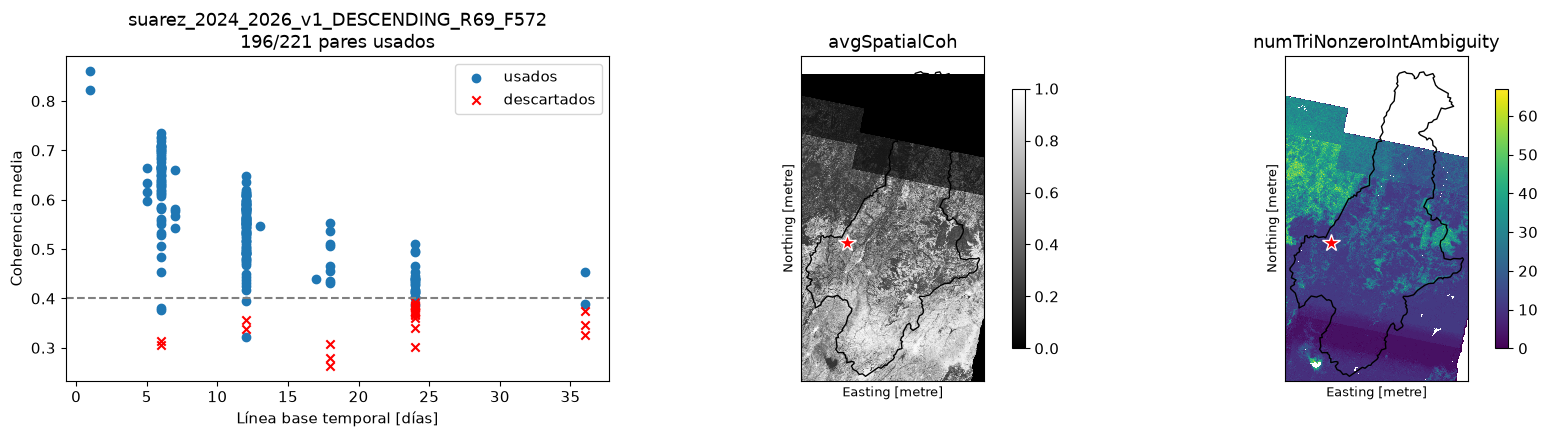

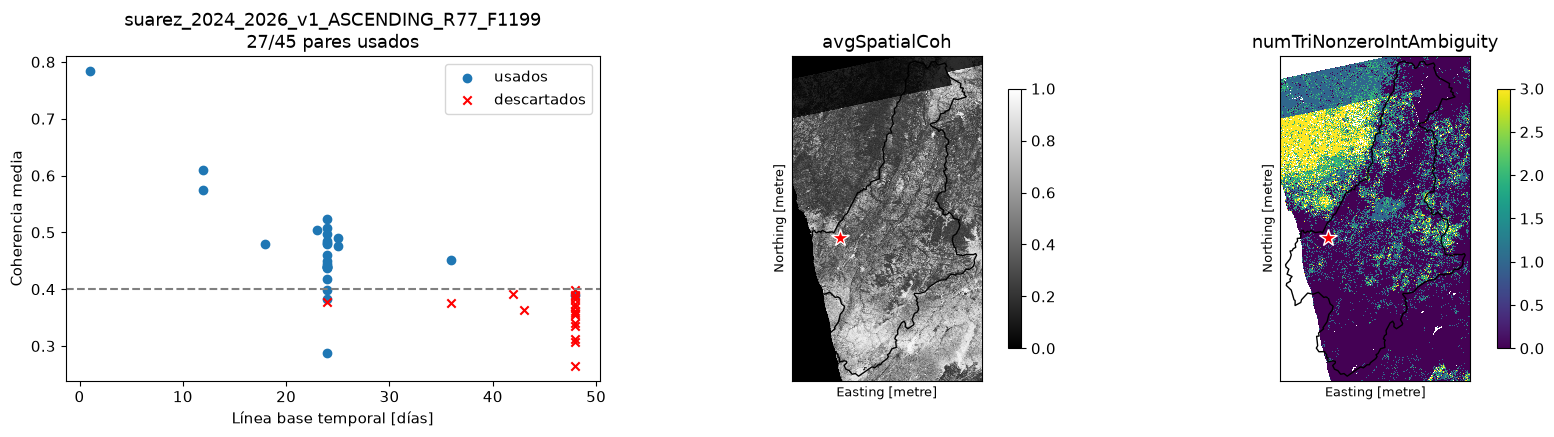

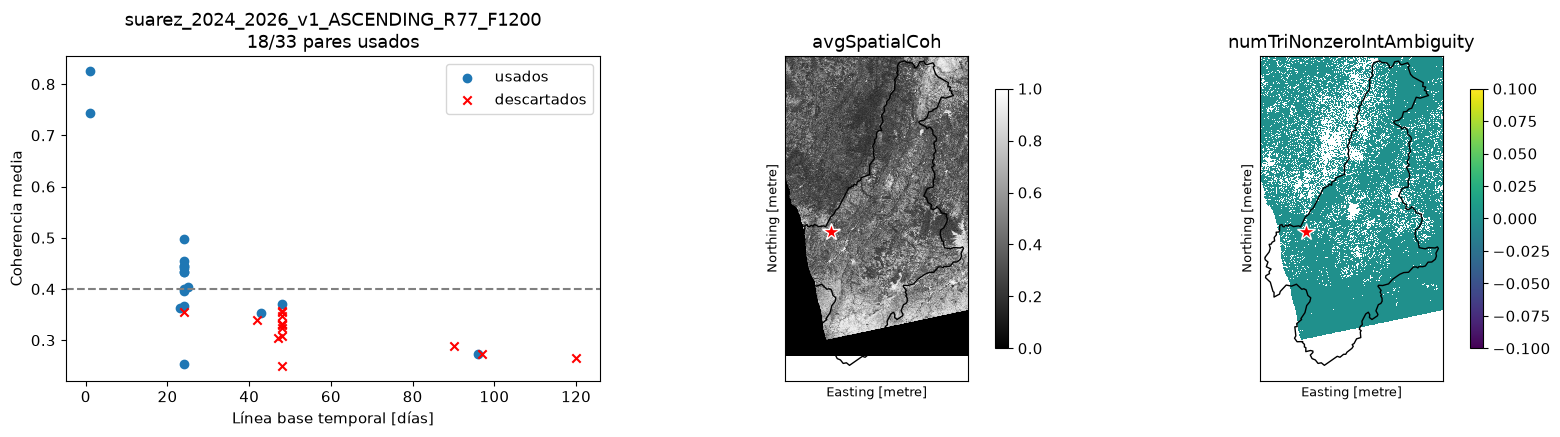

In [24]:
def leer_h5(archivo, dataset=None, indice=None):
    """Lee un dataset de un .h5 de MintPy. Devuelve (datos, atributos como dict de str).
    Si dataset=None usa el primero. `indice` permite leer una sola capa de un cubo 3D."""
    with h5py.File(archivo, "r") as f:
        dataset = dataset or list(f.keys())[0]
        d = f[dataset]
        datos = d[indice] if indice is not None else d[()]
        attrs = {k: (v.decode() if isinstance(v, bytes) else str(v)) for k, v in f.attrs.items()}
    return datos, attrs


def georef(attrs):
    """Transformada affine y CRS (EPSG) a partir de los atributos de MintPy (X_FIRST, Y_FIRST, X_STEP, Y_STEP)."""
    transform = from_origin(float(attrs["X_FIRST"]), float(attrs["Y_FIRST"]),
                            float(attrs["X_STEP"]), -float(attrs["Y_STEP"]))
    if "EPSG" in attrs and attrs["EPSG"] not in ("None", ""):
        epsg = int(attrs["EPSG"])
    elif "UTM_ZONE" in attrs:
        z = attrs["UTM_ZONE"]
        epsg = (32600 if z[-1].upper() == "N" else 32700) + int(re.sub(r"\D", "", z))
    else:
        epsg = 4326
    return transform, epsg


def extent(attrs):
    """Extensión [xmin, xmax, ymin, ymax] para imshow."""
    t, _ = georef(attrs)
    L, W = int(attrs["LENGTH"]), int(attrs["WIDTH"])
    return [t.c, t.c + W * t.a, t.f + L * t.e, t.f]


def dibujar_contexto(ax, epsg, attrs=None):
    """Dibuja la cuenca, el evento y el punto de referencia (si existe) en el CRS del producto."""
    gdf_cuenca.to_crs(epsg).boundary.plot(ax=ax, color="k", lw=1)
    ev = gpd.GeoSeries([PUNTO_EVENTO], crs=4326).to_crs(epsg).iloc[0]
    ax.plot(ev.x, ev.y, "r*", ms=13, mec="w")
    if attrs and "REF_LAT" in attrs:
        ref = gpd.GeoSeries([Point(float(attrs["REF_LON"]), float(attrs["REF_LAT"]))], crs=4326).to_crs(epsg).iloc[0]
        ax.plot(ref.x, ref.y, "ks", ms=7, mfc="w")
    ax.set_xticks([]); ax.set_yticks([])


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    stack = d / "inputs" / "ifgramStack.h5"
    if not stack.exists():
        print("Sin ifgramStack.h5:", job_name); continue
    with h5py.File(stack, "r") as f:
        fechas = [[str(x.decode() if isinstance(x, bytes) else x) for x in par] for par in f["date"][()]]
        drop = f["dropIfgram"][()]
        coh_media = np.array([np.nanmean(np.where(f["coherence"][i] > 0, f["coherence"][i], np.nan))
                              for i in range(f["coherence"].shape[0])])
    btemp = [(pd.Timestamp(b) - pd.Timestamp(a)).days for a, b in fechas]

    paneles = [p for p in ["avgSpatialCoh.h5", "numTriNonzeroIntAmbiguity.h5"] if (d / p).exists()]
    fig, axes = plt.subplots(1, 1 + len(paneles), figsize=(6 + 5 * len(paneles), 4.5))
    axes = np.atleast_1d(axes)
    axes[0].scatter(np.array(btemp)[drop], coh_media[drop], c="C0", label="usados")
    axes[0].scatter(np.array(btemp)[~drop], coh_media[~drop], c="r", marker="x", label="descartados")
    axes[0].axhline(COH_RED_MIN, color="gray", ls="--")
    axes[0].set(xlabel="Línea base temporal [días]", ylabel="Coherencia media", title=f"{job_name}\n{drop.sum()}/{len(drop)} pares usados")
    axes[0].legend()
    for ax, p in zip(axes[1:], paneles):
        data, at = leer_h5(d / p)
        _, epsg = georef(at)
        im = ax.imshow(data, extent=extent(at), cmap="gray" if "Coh" in p else "viridis",
                       vmin=0, vmax=1 if "Coh" in p else None, interpolation="nearest")
        dibujar_contexto(ax, epsg, leer_h5(stack, "dropIfgram")[1])
        ax.set_title(p.replace(".h5", ""))
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()

In [25]:
JOBS = [j for j in JOBS if "F1200" not in j]
print(JOBS)

['suarez_2024_2026_v1_DESCENDING_R69_F572', 'suarez_2024_2026_v1_ASCENDING_R77_F1199']


## 10.3 Bloque B: inversión, correcciones y velocidad
🔁 **Ejecutar siempre** (cada vez que abra el notebook). *(la corrección ERA5 descarga datos la primera vez; después usa la caché de `WEATHER_DIR`)*

**Qué hace:** en cada stack corre `smallbaselineApp.py config.txt --start correct_unwrap_error`, es decir, del bloque A hasta el final: corrección de desenrollado → **inversión de la red** (`timeseries.h5`, `temporalCoherence.h5`) → mareas terrestres (`timeseries_SET.h5`) → troposfera (`*_ERA5.h5`) → error de DEM (`*_demErr.h5`) → RMS de residuos y **fecha de referencia óptima** → **velocidad y funciones temporales** (`velocity.h5`) → KMZ.
Si un stack falla, sigue con el siguiente y el error queda en el log.
**Referencia:** secciones 3.5, 3.6 y 4.2 del notebook `smallbaselineApp_aria.ipynb` del curso ISCE+ 2026 [R1]; Yunjun et al. (2019) [P1]; Fattahi & Amelung (2013) [P3]; Pepe & Lanari (2006) sobre coherencia temporal [P6].

In [26]:
for j in JOBS:
    cfg = MINTPY_ROOT / j / "config.txt"
    txt = cfg.read_text()
    txt = re.sub(r"^mintpy\.compute\.cluster\s*=.*$", "mintpy.compute.cluster = none", txt, flags=re.M)
    txt = re.sub(r"^mintpy\.compute\.numWorker\s*=.*$", "mintpy.compute.maxMemory = 8", txt, flags=re.M)
    cfg.write_text(txt)
    estado_mintpy[j] = "A_ok"
    print(j, "→", [l for l in txt.splitlines() if "compute" in l])

suarez_2024_2026_v1_DESCENDING_R69_F572 → ['mintpy.compute.cluster = none', 'mintpy.compute.maxMemory = 8']
suarez_2024_2026_v1_ASCENDING_R77_F1199 → ['mintpy.compute.cluster = none', 'mintpy.compute.maxMemory = 8']


In [27]:
estado_mintpy = globals().get("estado_mintpy", {})
for job_name in tqdm(JOBS, desc="MintPy bloque B", bar_format=BARRA_FORMATO, colour="#9C27B0"):
    if estado_mintpy.get(job_name, "A_ok") != "A_ok":
        print("Saltando (falló el bloque A):", job_name); continue
    rc = ejecutar_mintpy("smallbaselineApp", ["config.txt", "--start", "correct_unwrap_error"],
                         cwd=MINTPY_ROOT / job_name, check=False)
    estado_mintpy[job_name] = "B_ok" if rc == 0 else "B_error"

display(pd.Series(estado_mintpy, name="estado"))
print("Logs en:", [str(MINTPY_ROOT / j / "log_mintpy.txt") for j in JOBS])

MintPy bloque B   0% |                                   | 0/2 [00:00<?]

suarez_2024_2026_v1_DESCENDING_R69_F572    B_ok
suarez_2024_2026_v1_ASCENDING_R77_F1199    B_ok
suarez_2024_2026_v1_ASCENDING_R77_F1200    A_ok
Name: estado, dtype: str

Logs en: ['mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_DESCENDING_R69_F572/log_mintpy.txt', 'mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_ASCENDING_R77_F1199/log_mintpy.txt']


# 11. Resultados

**Convención de signos (MintPy):** valores **positivos** = el terreno se **acerca** al satélite (levantamiento o movimiento hacia el sensor). Valores **negativos** = se **aleja** (subsidencia o movimiento que se aleja del sensor). Las velocidades se muestran en **mm/año en LOS** y son **relativas al punto de referencia** (curso ISCE+, nota de la sección 3.6 [R1]).

## 11.1 Serie temporal final y máscara de confiabilidad
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:**
- `serie_final()` encuentra el archivo de serie temporal **con más correcciones**. MintPy agrega un sufijo por cada una: `timeseries_SET_ERA5_demErr.h5`.
- `mascara_confiable()` combina: coherencia temporal ≥ 0.7 (`maskTempCoh.h5`), coherencia espacial promedio ≥ `COH_ESPACIAL_MIN` y la máscara de agua.

**Por qué las dos coherencias:** en una red secuencial (1 vecino), la coherencia temporal es ≈ 1 en todas partes y no filtra nada. En ese caso la coherencia espacial promedio es la que separa los píxeles confiables. Este es el punto que se discute en las preguntas de la sección 4.1.1 del notebook del curso [R1].
**Referencia:** `generate_mask.py` y las máscaras del curso [R1]; coherencia temporal (Pepe & Lanari, 2006 [P6]; Yunjun et al., 2019 [P1]).

In [28]:
COH_ESPACIAL_MIN = 0.3   # ✏️ súbalo a 0.4–0.5 si el mapa sale muy ruidoso


def serie_final(mintpy_dir):
    """Archivo timeseries*.h5 con la cadena de correcciones más larga (excluye los residuales)."""
    cands = [p for p in Path(mintpy_dir).glob("timeseries*.h5") if "Residual" not in p.name]
    if not cands:
        raise FileNotFoundError(f"No hay timeseries*.h5 en {mintpy_dir}")
    return max(cands, key=lambda p: len(p.stem))


def mascara_confiable(mintpy_dir):
    """Máscara booleana de píxeles confiables (coherencia temporal, coherencia espacial y agua)."""
    d = Path(mintpy_dir)
    m = leer_h5(d / "maskTempCoh.h5")[0].astype(bool)
    if (d / "avgSpatialCoh.h5").exists():
        m &= leer_h5(d / "avgSpatialCoh.h5")[0] >= COH_ESPACIAL_MIN
    with h5py.File(d / "inputs" / "geometryGeo.h5", "r") as f:
        if "waterMask" in f:
            m &= f["waterMask"][()].astype(bool)
    return m


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        print(f"{job_name}: sin velocity.h5 (revise el log)"); continue
    m = mascara_confiable(d)
    print(f"{job_name}\n  serie final: {serie_final(d).name}\n  píxeles confiables: {100 * m.mean():.1f} %")

suarez_2024_2026_v1_DESCENDING_R69_F572
  serie final: timeseries_SET_ERA5_demErr.h5
  píxeles confiables: 44.1 %
suarez_2024_2026_v1_ASCENDING_R77_F1199
  serie final: timeseries_SET_ERA5_demErr.h5
  píxeles confiables: 58.2 %


## 11.2 Mapas de velocidad LOS y de incertidumbre
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** para cada stack grafica la velocidad (`velocity`, mm/año) con la máscara de confiabilidad y una escala simétrica en los percentiles 2 y 98, junto con su desviación estándar (`velocityStd`). Encima dibuja la cuenca, el evento (★) y el punto de referencia (■).
**Cómo leer `velocityStd`:** solo mide qué tan bien se ajusta el modelo temporal. Crece con la distancia al punto de referencia porque el ruido atmosférico está correlacionado espacialmente, y **puede subestimar** la incertidumbre real (discusión de la sección 3.6 del curso [R1]).
**Referencia:** `view.py velocity.h5 velocity` y `velocityStd` en el curso ISCE+ [R1]; `timeseries2velocity.py` [R7], [R8].

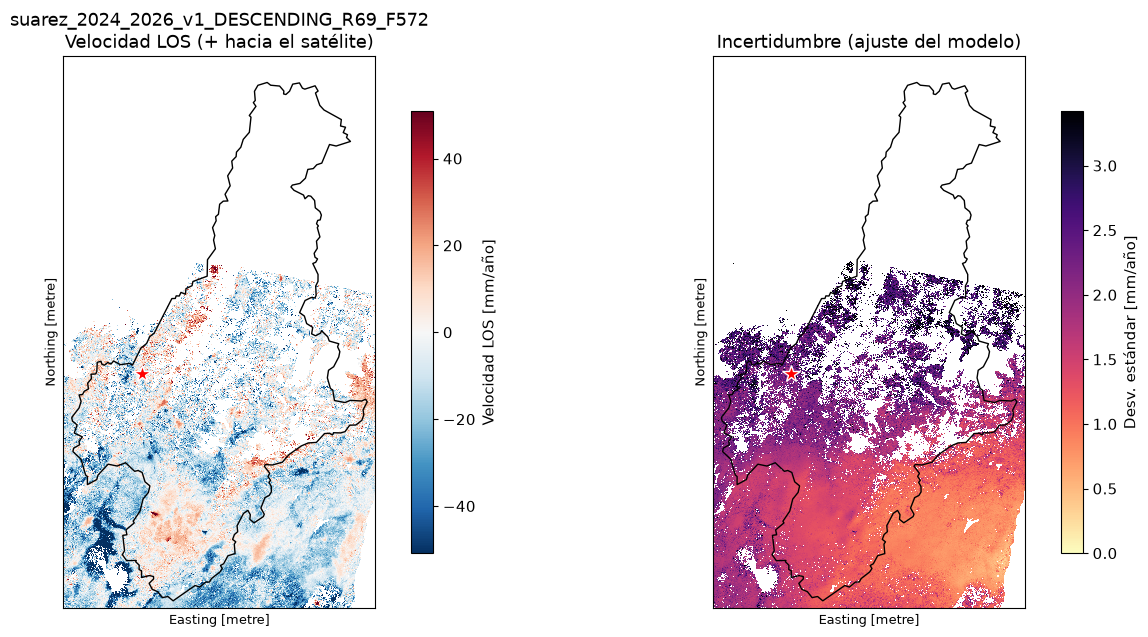

  Dentro de la máscara: mediana -7.0 mm/año | P2–P98: -50.2 a 22.2 mm/año


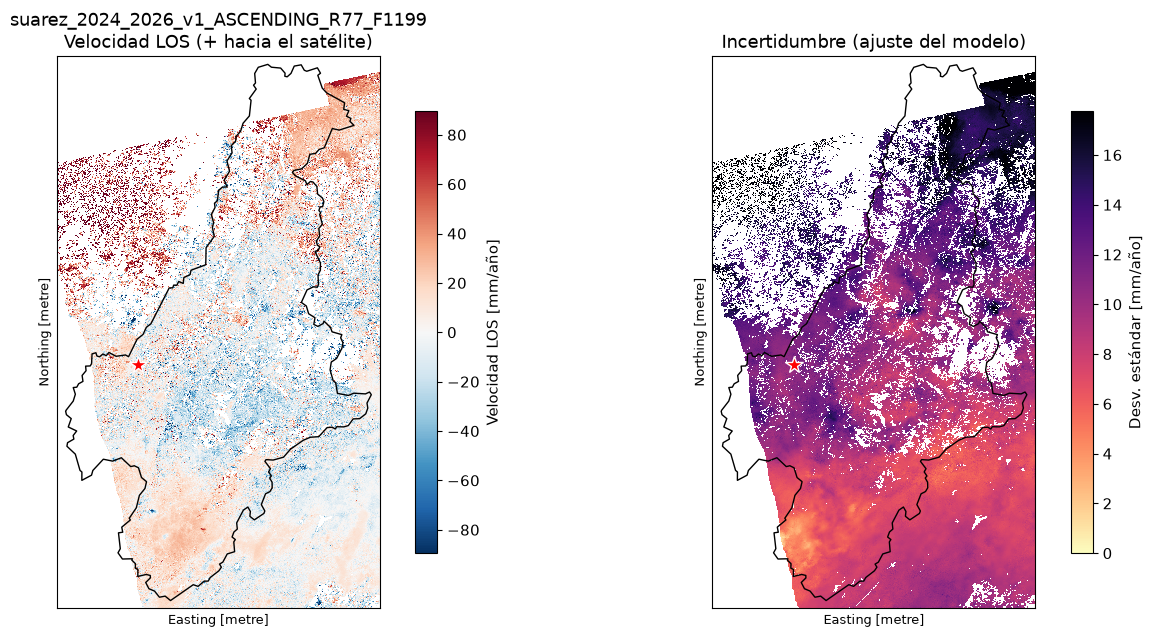

  Dentro de la máscara: mediana 2.5 mm/año | P2–P98: -50.5 a 84.7 mm/año


In [29]:
def lim_simetrico(arr, p=98):
    """Límite simétrico para la escala de colores a partir del percentil p del valor absoluto."""
    v = np.nanpercentile(np.abs(arr), p)
    return float(v) if np.isfinite(v) and v > 0 else 1.0


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    std, _ = leer_h5(d / "velocity.h5", "velocityStd")
    _, epsg = georef(at)
    m = mascara_confiable(d)
    vel_mm = np.where(m, vel * 1000, np.nan)
    std_mm = np.where(m, std * 1000, np.nan)
    vlim = lim_simetrico(vel_mm)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
    im0 = axes[0].imshow(vel_mm, extent=extent(at), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
    im1 = axes[1].imshow(std_mm, extent=extent(at), cmap="magma_r", vmin=0,
                         vmax=np.nanpercentile(std_mm, 98), interpolation="nearest")
    for ax in axes:
        dibujar_contexto(ax, epsg, at)
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Velocidad LOS [mm/año]")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Desv. estándar [mm/año]")
    axes[0].set_title(f"{job_name}\nVelocidad LOS (+ hacia el satélite)")
    axes[1].set_title("Incertidumbre (ajuste del modelo)")
    plt.tight_layout(); plt.show()
    print(f"  Dentro de la máscara: mediana {np.nanmedian(vel_mm):.1f} mm/año | "
          f"P2–P98: {np.nanpercentile(vel_mm, 2):.1f} a {np.nanpercentile(vel_mm, 98):.1f} mm/año")

## 11.3 Escalón del evento y componentes estacionales
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** si el stack cubre el evento, `velocity.h5` trae el dataset `step<AAAAMMDD>`, que es el **desplazamiento repentino** en la fecha del evento estimado con la función escalón. La celda lo grafica en cm junto con la **amplitud anual y semestral** (`annualAmplitude` y `semiAnnualAmplitude`), que muestran la respuesta estacional, por ejemplo a la humedad del suelo o a laderas que se mueven con las lluvias.
**Referencia:** estimación de funciones temporales `mintpy.timeFunc.*` y `timeseries2velocity.py --poly --periodic --step`, sección 6.1 del notebook del curso ISCE+ [R1]; Hetland et al. (2012) [P7].

In [ ]:
for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    with h5py.File(d / "velocity.h5", "r") as f:
        claves = [k for k in f.keys() if (k.startswith("step") and not k.endswith("Std"))
                  or k in ("annualAmplitude", "semiAnnualAmplitude")]
    if not claves:
        print(f"{job_name}: sin escalón ni términos periódicos."); continue
    m = mascara_confiable(d)
    fig, axes = plt.subplots(1, len(claves), figsize=(6.5 * len(claves), 6), squeeze=False)
    for ax, k in zip(axes[0], claves):
        data, at = leer_h5(d / "velocity.h5", k)
        _, epsg = georef(at)
        data_cm = np.where(m, data * 100, np.nan)
        if k.startswith("step"):
            vlim = lim_simetrico(data_cm)
            im = ax.imshow(data_cm, extent=extent(at), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
        else:
            im = ax.imshow(data_cm, extent=extent(at), cmap="viridis", vmin=0,
                           vmax=np.nanpercentile(data_cm, 98), interpolation="nearest")
        dibujar_contexto(ax, epsg, at)
        plt.colorbar(im, ax=ax, shrink=0.8, label="[cm]")
        ax.set_title(f"{job_name}\n{k}")
    plt.tight_layout(); plt.show()

## 11.4 Series temporales en puntos de interés
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** en cada punto de `PUNTOS` (lat, lon) toma el promedio de una ventana de 3×3 píxeles de la **serie temporal final**, usando solo los píxeles confiables. Grafica el desplazamiento LOS en cm, relativo a la primera fecha, con la fecha del evento marcada. Siempre incluye el punto del evento. Agregue aquí escarpes, vías o sitios con inventario de movimientos en masa.
**Por qué 3×3:** reduce el ruido de un solo píxel sin mezclar señales distintas; a unos 80 m por píxel, la ventana cubre ≈ 240 m.
**Referencia:** `tsview.py` del curso ISCE+ (secciones 6.1 y 6.5) [R1]; estructura de `timeseries.h5` [R11].

In [ ]:
PUNTOS = {
    "Evento Vélez": (PUNTO_EVENTO.y, PUNTO_EVENTO.x),
    # "Otro sitio": (6.30, -73.40),   # ✏️ (lat, lon)
}


def serie_en_punto(mintpy_dir, lat, lon, ventana=1):
    """Serie temporal (cm) promediada en una ventana (2*ventana+1)² alrededor de (lat, lon).
    Devuelve (fechas, valores) o (None, None) si el punto está fuera o sin píxeles confiables."""
    archivo = serie_final(mintpy_dir)
    with h5py.File(archivo, "r") as f:
        attrs = {k: (v.decode() if isinstance(v, bytes) else str(v)) for k, v in f.attrs.items()}
        transform, epsg = georef(attrs)
        x, y = Transformer.from_crs(4326, epsg, always_xy=True).transform(lon, lat)
        r, c = rowcol(transform, x, y)
        L, W = f["timeseries"].shape[1:]
        if not (0 <= r < L and 0 <= c < W):
            return None, None
        r0, r1, c0, c1 = max(r - ventana, 0), min(r + ventana + 1, L), max(c - ventana, 0), min(c + ventana + 1, W)
        cubo = f["timeseries"][:, r0:r1, c0:c1]
        fechas = pd.to_datetime(f["date"][()].astype(str))
    m = mascara_confiable(mintpy_dir)[r0:r1, c0:c1]
    if not m.any():
        return fechas, None
    serie = np.nanmean(np.where(m, cubo, np.nan), axis=(1, 2)) * 100
    return fechas, serie - serie[0]


for nombre, (lat, lon) in PUNTOS.items():
    fig, ax = plt.subplots(figsize=(12, 4))
    for job_name in JOBS:
        d = MINTPY_ROOT / job_name
        if not (d / "velocity.h5").exists():
            continue
        fechas, serie = serie_en_punto(d, lat, lon)
        if serie is None:
            print(f"{nombre} / {job_name}: fuera del área o sin píxeles confiables"); continue
        ax.plot(fechas, serie, "o-", ms=4, label=job_name.replace(f"{RUN_ID}_", ""))
        if FECHA_EVENTO:
        ax.axvline(FECHA_EVENTO, color="r", ls="--", label="Evento")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set(title=f"Serie temporal LOS — {nombre} ({lat:.4f}, {lon:.4f})", ylabel="Desplazamiento LOS [cm]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.legend(); plt.tight_layout(); plt.show()

## 11.5 Exportar a GeoTIFF (QGIS / ArcGIS)
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** en cada stack exporta a `mintpy_<RUN_ID>/<job>/geotiff/`:
- `velocidad_mm_anio.tif` (con la máscara de confiabilidad);
- `velocidad_std_mm_anio.tif`;
- `mascara_confiable.tif`;
- `step_cm.tif`, si existe el escalón;
- las mismas capas **recortadas a la cuenca** (`*_cuenca.tif`).

Los archivos quedan en el CRS UTM del producto, con `NaN` como *nodata*. MintPy también deja `velocity.kmz` para Google Earth.
**Referencia:** equivale a `save_gdal.py velocity.h5 -d velocity` de MintPy (sección 6.8 del curso [R1]), escrito con rasterio en el kernel [R14]; recorte con `rasterio.features.geometry_mask` [R14].

In [30]:
def guardar_tif(ruta, arr, attrs):
    """Escribe un GeoTIFF float32 con la georreferencia de MintPy."""
    transform, epsg = georef(attrs)
    perfil = dict(driver="GTiff", height=arr.shape[0], width=arr.shape[1], count=1, dtype="float32",
                  crs=f"EPSG:{epsg}", transform=transform, nodata=np.nan, compress="deflate")
    with rasterio.open(ruta, "w", **perfil) as dst:
        dst.write(arr.astype("float32"), 1)


for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        continue
    out = d / "geotiff"; out.mkdir(exist_ok=True)
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    std, _ = leer_h5(d / "velocity.h5", "velocityStd")
    m = mascara_confiable(d)
    transform, epsg = georef(at)
    fuera = geometry_mask(gdf_cuenca.to_crs(epsg).geometry, out_shape=vel.shape, transform=transform)

    capas = {"velocidad_mm_anio": np.where(m, vel * 1000, np.nan),
             "velocidad_std_mm_anio": np.where(m, std * 1000, np.nan),
             "mascara_confiable": m.astype("float32")}
    with h5py.File(d / "velocity.h5", "r") as f:
        for k in f.keys():
            if k.startswith("step") and not k.endswith("Std"):
                capas["step_cm"] = np.where(m, f[k][()] * 100, np.nan)

    for nombre, arr in capas.items():
        guardar_tif(out / f"{nombre}.tif", arr, at)
        guardar_tif(out / f"{nombre}_cuenca.tif", np.where(fuera, np.nan, arr), at)
    print(f"✅ {job_name}: {len(capas) * 2} GeoTIFF en {out}")

✅ suarez_2024_2026_v1_DESCENDING_R69_F572: 6 GeoTIFF en mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_DESCENDING_R69_F572/geotiff
✅ suarez_2024_2026_v1_ASCENDING_R77_F1199: 6 GeoTIFF en mintpy_suarez_2024_2026_v1/suarez_2024_2026_v1_ASCENDING_R77_F1199/geotiff


## 11.6 Resumen por stack
🔁 **Ejecutar siempre** (cada vez que abra el notebook).

**Qué hace:** tabla final con el número de fechas y pares, los pares usados, la fecha de referencia elegida por MintPy (`reference_date.txt`), las fechas excluidas por RMS alto (`exclude_date.txt`), el porcentaje de píxeles confiables dentro de la cuenca y las estadísticas de velocidad. Es la tabla para el informe.
**Referencia:** pasos `residual_RMS` y `reference_date` (secciones 4.2.8 y 4.2.9 del curso ISCE+ [R1]).

In [ ]:
estado_mintpy = globals().get("estado_mintpy", {})
filas = []
for job_name in JOBS:
    d = MINTPY_ROOT / job_name
    if not (d / "velocity.h5").exists():
        filas.append({"stack": job_name, "estado": estado_mintpy.get(job_name, "sin resultado")}); continue
    vel, at = leer_h5(d / "velocity.h5", "velocity")
    transform, epsg = georef(at)
    dentro = ~geometry_mask(gdf_cuenca.to_crs(epsg).geometry, out_shape=vel.shape, transform=transform)
    m = mascara_confiable(d) & dentro
    v = vel[m] * 1000
    drop = leer_h5(d / "inputs" / "ifgramStack.h5", "dropIfgram")[0]
    leer_txt = lambda p: (d / p).read_text().split() if (d / p).exists() else []
    filas.append({
        "stack": job_name.replace(f"{RUN_ID}_", ""),
        "fechas": info_red[job_name]["n_fechas"], "pares": len(drop), "pares_usados": int(drop.sum()),
        "fecha_ref": ",".join(leer_txt("reference_date.txt")),
        "fechas_excluidas": ",".join(leer_txt("exclude_date.txt")) or "-",
        "ref_lat_lon": f"{float(at.get('REF_LAT', 'nan')):.4f}, {float(at.get('REF_LON', 'nan')):.4f}",
        "%_confiable_cuenca": round(100 * m.sum() / max(dentro.sum(), 1), 1),
        "vel_mediana_mm": round(float(np.median(v)), 1) if v.size else np.nan,
        "vel_P2_mm": round(float(np.percentile(v, 2)), 1) if v.size else np.nan,
        "vel_P98_mm": round(float(np.percentile(v, 98)), 1) if v.size else np.nan,
    })
resumen_df = pd.DataFrame(filas)
display(resumen_df)
resumen_df.to_csv(MINTPY_ROOT / f"{RUN_ID}_resumen_mintpy.csv", index=False)

## 12. Descomposición ascendente/descendente → vertical y Este-Oeste (opcional)
🔁 **Ejecutar siempre** (cada vez que abra el notebook). *(solo si hay al menos un stack ASCENDING y uno DESCENDING)*

**Qué hace:**
1. toma la velocidad de un stack ascendente y uno descendente y la **remuestrea a una grilla común**, la del ascendente, con `rasterio.warp.reproject`, junto con sus ángulos de incidencia y azimut (`inputs/geometryGeo.h5`);
2. en cada píxel resuelve el sistema 2×2
$$v_{LOS} = -\sin\theta\,\sin\alpha\;v_E + \cos\theta\;v_U$$
con la convención de MintPy (`utils0.enu2los`; α = azimut del vector LOS, positivo antihorario desde el norte). Se **desprecia la componente Norte**, a la que Sentinel-1 es casi ciego por su órbita casi polar.

**Condiciones:** ambos stacks deben tener **el mismo punto de referencia**, así que defina `REF_LALO` en 9.5 y vuelva a correr la sección 10. También deben cubrir un periodo parecido. En laderas, la componente E-O incluye el movimiento a favor de la pendiente.
**Referencia:** `4.2_Decomposition_of_velocities_from_multiple_viewing_geometries/simple_los_decomposition_berkeley_landslides.ipynb` y `decompose_mintpy_velocities.ipynb` del curso ISCE+ 2026 [R1]; `asc_desc2horz_vert.py` de MintPy [R7]; Wright et al. (2004) [P8].

In [ ]:
from rasterio.warp import reproject, Resampling


def cargar_para_descomposicion(mintpy_dir):
    """Velocidad enmascarada (m/año), incidencia y azimut (grados) y atributos de un stack."""
    vel, at = leer_h5(mintpy_dir / "velocity.h5", "velocity")
    vel = np.where(mascara_confiable(mintpy_dir), vel, np.nan)
    inc = leer_h5(mintpy_dir / "inputs" / "geometryGeo.h5", "incidenceAngle")[0]
    az = leer_h5(mintpy_dir / "inputs" / "geometryGeo.h5", "azimuthAngle")[0]
    return vel, inc, az, at


def a_grilla(arr, at_src, at_dst):
    """Remuestrea arr de la grilla src a la grilla dst (bilineal, NaN como nodata)."""
    t_src, e_src = georef(at_src)
    t_dst, e_dst = georef(at_dst)
    out = np.full((int(at_dst["LENGTH"]), int(at_dst["WIDTH"])), np.nan, dtype="float32")
    reproject(arr.astype("float32"), out, src_transform=t_src, src_crs=f"EPSG:{e_src}",
              dst_transform=t_dst, dst_crs=f"EPSG:{e_dst}", resampling=Resampling.bilinear,
              src_nodata=np.nan, dst_nodata=np.nan)
    return out


asc = [j for j in JOBS if "ASC" in j.upper() and (MINTPY_ROOT / j / "velocity.h5").exists()]
dsc = [j for j in JOBS if "DESC" in j.upper() and (MINTPY_ROOT / j / "velocity.h5").exists()]

if not (asc and dsc):
    print("Se necesita al menos un stack ascendente y uno descendente con resultados. Se omite.")
else:
    ja, jd = asc[0], dsc[0]
    va, ia, aa, ata = cargar_para_descomposicion(MINTPY_ROOT / ja)
    vd, idd, ad, atd = cargar_para_descomposicion(MINTPY_ROOT / jd)
    if abs(float(ata.get("REF_LAT", 0)) - float(atd.get("REF_LAT", 1))) > 0.005:
        print("⚠️ Los puntos de referencia no coinciden: defina REF_LALO en 9.5 y vuelva a correr la sección 10.")
    vd, idd, ad = (a_grilla(x, atd, ata) for x in (vd, idd, ad))

    ia_r, aa_r, id_r, ad_r = map(np.deg2rad, (ia, aa, idd, ad))
    # Matriz de diseño por píxel: filas = [asc, desc], columnas = [E, U]
    a11, a12 = -np.sin(ia_r) * np.sin(aa_r), np.cos(ia_r)
    a21, a22 = -np.sin(id_r) * np.sin(ad_r), np.cos(id_r)
    det = a11 * a22 - a12 * a21
    ok = np.isfinite(va) & np.isfinite(vd) & (np.abs(det) > 1e-3)
    vE = np.where(ok, (a22 * va - a12 * vd) / det, np.nan) * 1000
    vU = np.where(ok, (-a21 * va + a11 * vd) / det, np.nan) * 1000

    _, epsg = georef(ata)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
    for ax, arr, titulo in zip(axes, [vU, vE], ["Vertical (+ arriba)", "Este-Oeste (+ Este)"]):
        vlim = lim_simetrico(arr)
        im = ax.imshow(arr, extent=extent(ata), cmap="RdBu_r", vmin=-vlim, vmax=vlim, interpolation="nearest")
        dibujar_contexto(ax, epsg, ata)
        plt.colorbar(im, ax=ax, shrink=0.8, label="[mm/año]")
        ax.set_title(f"{titulo}\n{ja.replace(RUN_ID + '_', '')} + {jd.replace(RUN_ID + '_', '')}")
    plt.tight_layout(); plt.show()

    out = MINTPY_ROOT / "descomposicion"; out.mkdir(exist_ok=True)
    guardar_tif(out / "vertical_mm_anio.tif", vU, ata)
    guardar_tif(out / "este_oeste_mm_anio.tif", vE, ata)
    print("✅ GeoTIFF en", out)

## Referencias

### Software, cursos y documentación [R]
- **[R1]** EarthScope Consortium (2026). *2026 Technical Course: InSAR Processing and Analysis (ISCE+)*, 3–7 de agosto de 2026. Materiales: https://github.com/isceplus/2026-isceplus — en particular:
  - `4.4_Intro_to_MintPy/smallbaselineApp_nisar.ipynb` (Hu, Yunjun & Fattahi, 2026);
  - `5.1_TSAnalysis_with_MintPy_ErrorAnalysis/smallbaselineApp_aria.ipynb` (Yunjun & Fattahi, 2026);
  - `4.2_Decomposition_of_velocities_from_multiple_viewing_geometries/` (descomposición Asc/Desc, ejemplo de deslizamientos en Berkeley);
  - `3.4_Tropo_Iono_Correction/`, `0.5_Data_Search_and_Access/`, `S07_Installing_the_course_environment_with_conda/`.
  Página del curso: https://www.earthscope.org/event/2026-technical-course-insar-processing-and-analysis-isce/
- **[R3]** ASF HyP3 — *Time series analysis with HyP3 and MintPy* (tutorial): https://github.com/ASFHyP3/hyp3-docs/blob/main/docs/tutorials/hyp3_insar_stack_for_ts_analysis.ipynb
- **[R4]** ASF HyP3 SDK — documentación y API: https://hyp3-docs.asf.alaska.edu/using/sdk/ · https://hyp3-docs.asf.alaska.edu/using/sdk_api/
- **[R5]** ASF — *Sentinel-1 InSAR Product Guide* (HyP3 GAMMA: nombres, capas `unw_phase`, `corr`, `lv_theta`, `lv_phi`, metadatos): https://hyp3-docs.asf.alaska.edu/guides/insar_product_guide/
- **[R6]** ASF — `asf_search`: https://docs.asf.alaska.edu/asf_search/basics/
- **[R7]** MintPy (código fuente): https://github.com/insarlab/MintPy — `src/mintpy/prep_hyp3.py`, `objects/stackDict.py`, `tropo_pyaps3.py`, `utils/utils0.py`, `cli/asc_desc2horz_vert.py`
- **[R8]** MintPy — plantilla `smallbaselineApp.cfg` (todas las opciones y sus valores por defecto): https://github.com/insarlab/MintPy/blob/main/src/mintpy/defaults/smallbaselineApp.cfg
- **[R9]** MintPy — estructura de directorios y configuración para HyP3: https://mintpy.readthedocs.io/en/latest/dir_structure/#hyp3
- **[R10]** MintPy — instalación: https://mintpy.readthedocs.io/en/latest/installation/
- **[R11]** MintPy — estructura de datos HDF5 (`ifgramStack.h5`, `timeseries.h5`, `velocity.h5`): https://mintpy.readthedocs.io/en/latest/api/data_structure/
- **[R12]** PyAPS3 (ERA5, configuración de `~/.cdsapirc`): https://github.com/insarlab/PyAPS
- **[R13]** PySolid (mareas terrestres): https://github.com/insarlab/PySolid
- **[R14]** Rasterio — lectura por ventanas, reproyección y enmascarado: https://rasterio.readthedocs.io/en/stable/topics/windowed-rw.html · https://rasterio.readthedocs.io/en/stable/topics/reproject.html · https://rasterio.readthedocs.io/en/stable/api/rasterio.features.html
- **[R15]** Shapely (https://shapely.readthedocs.io) y GeoPandas (https://geopandas.org).

### Artículos [P]
- **[P1]** Yunjun, Z., Fattahi, H., & Amelung, F. (2019). Small baseline InSAR time series analysis: Unwrapping error correction and noise reduction. *Computers & Geosciences, 133*, 104331. https://doi.org/10.1016/j.cageo.2019.104331
- **[P2]** Berardino, P., Fornaro, G., Lanari, R., & Sansosti, E. (2002). A new algorithm for surface deformation monitoring based on small baseline differential SAR interferograms. *IEEE TGRS, 40*(11), 2375–2383. https://doi.org/10.1109/TGRS.2002.803792
- **[P3]** Fattahi, H., & Amelung, F. (2013). DEM error correction in InSAR time series. *IEEE TGRS, 51*(7), 4249–4259. https://doi.org/10.1109/TGRS.2012.2227761
- **[P4]** Jolivet, R., Grandin, R., Lasserre, C., Doin, M.-P., & Peltzer, G. (2011). Systematic InSAR tropospheric phase delay corrections from global meteorological reanalysis data. *GRL, 38*, L17311. https://doi.org/10.1029/2011GL048757
- **[P5]** Yunjun, Z., Fattahi, H., Pi, X., Rosen, P., Simons, M., Agram, P., & Aoki, Y. (2022). Range geolocation accuracy of C-/L-band SAR and its implications for operational stack coregistration. *IEEE TGRS, 60*. https://doi.org/10.1109/TGRS.2022.3168509
- **[P6]** Pepe, A., & Lanari, R. (2006). On the extension of the minimum cost flow algorithm for phase unwrapping of multitemporal differential SAR interferograms. *IEEE TGRS, 44*(9), 2374–2383. https://doi.org/10.1109/TGRS.2006.873207
- **[P7]** Hetland, E. A., Musé, P., Simons, M., Lin, Y. N., Agram, P. S., & DiCaprio, C. J. (2012). Multiscale InSAR Time Series (MInTS) analysis of surface deformation. *JGR: Solid Earth, 117*, B02404. https://doi.org/10.1029/2011JB008731
- **[P8]** Wright, T. J., Parsons, B. E., & Lu, Z. (2004). Toward mapping surface deformation in three dimensions using InSAR. *GRL, 31*, L01607. https://doi.org/10.1029/2003GL018827
- **[P9]** Hersbach, H., et al. (2020). The ERA5 global reanalysis. *QJRMS, 146*(730), 1999–2049. https://doi.org/10.1002/qj.3803
- **[P10]** Doin, M.-P., Lasserre, C., Peltzer, G., Cavalié, O., & Doubre, C. (2009). Corrections of stratified tropospheric delays in SAR interferometry: Validation with global atmospheric models. *Journal of Applied Geophysics, 69*(1), 35–50. https://doi.org/10.1016/j.jappgeo.2009.03.010